In [11]:
from __future__ import annotations

import os
import re
import warnings
from dataclasses import asdict, dataclass
from pathlib import Path
from typing import Any, Iterable

import joblib
import matplotlib.image as mpimg
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression, Ridge
from sklearn.metrics import (
    average_precision_score,
    brier_score_loss,
    log_loss,
    r2_score,
    roc_auc_score,
)
from sklearn.model_selection import GroupKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from xgboost import XGBClassifier

In [ ]:
PROJECT_DIR = Path.cwd()

if PROJECT_DIR.name.lower() == "notebooks":
    PROJECT_DIR = PROJECT_DIR.parent

DATA_DIR = PROJECT_DIR / "data" / "raw"
OUTPUT_DIR = PROJECT_DIR / "outputs"
EXAMPLES_DIR = PROJECT_DIR / "examples"
ASSETS_DIR = PROJECT_DIR / "assets"

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
EXAMPLES_DIR.mkdir(parents=True, exist_ok=True)

DATA_FILE_NAME = "2025 CCBL Trackman Data.xlsx"

DATA_FILE_OVERRIDE: str | Path | None = Path(
    r"C:\Users\brend\OneDrive\ccbl-stuff-plus\data\raw\2025 CCBL Trackman Data.xlsx"
)
if DATA_FILE_OVERRIDE is not None and not Path(DATA_FILE_OVERRIDE).exists():
    raise FileNotFoundError(f"Workbook override not found: {DATA_FILE_OVERRIDE}. Update DATA_FILE_OVERRIDE to your workbook location.")

environment_data_file = os.getenv("CCBL_TRACKMAN_FILE")
data_candidates: list[Path] = []
if DATA_FILE_OVERRIDE is not None:
    data_candidates.append(Path(DATA_FILE_OVERRIDE).expanduser())
if environment_data_file:
    data_candidates.append(Path(environment_data_file).expanduser())
data_candidates.extend(
    [
        DATA_DIR / DATA_FILE_NAME,
        PROJECT_DIR / DATA_FILE_NAME,
    ]
)

DATA_FILE = next(
    (candidate for candidate in data_candidates if candidate.exists()),
    DATA_DIR / DATA_FILE_NAME,
)
DATA_FILES = [DATA_FILE]

MODEL_VERSION = "CCBL-StuffPlus-G-v1.0"
RUN_MODEL = True

G_RUN_DIRECTORY: Path | None = None

from datetime import datetime, timezone
if G_RUN_DIRECTORY is None:
    if not RUN_MODEL:
        raise ValueError("Set G_RUN_DIRECTORY to a completed G output folder when RUN_MODEL=False.")
    G_RUN_DIRECTORY = OUTPUT_DIR / "stuffplus_g_v1" / datetime.now(timezone.utc).strftime("run_%Y%m%dT%H%M%S_%fZ")
G_RUN_DIRECTORY = Path(G_RUN_DIRECTORY)
G_RUN_DIRECTORY.mkdir(parents=True, exist_ok=True)
OUTPUT_PATH = G_RUN_DIRECTORY / "StuffPlus_G_AllPitchScores.xlsx"
MODEL_BUNDLE_PATH = G_RUN_DIRECTORY / "StuffPlus_G_models.joblib"
REPORT_DATA_PATH = G_RUN_DIRECTORY / "StuffPlus_G_report_data.joblib"
MANIFEST_PATH = G_RUN_DIRECTORY / "StuffPlus_G_manifest.json"
if RUN_MODEL and any(p.exists() for p in [OUTPUT_PATH, MODEL_BUNDLE_PATH, REPORT_DATA_PATH]):
    raise FileExistsError("This G folder already contains model outputs. Choose a new folder or set RUN_MODEL=False to generate reports from the saved run.")

PITCHER_NAME = "Keenan, Aidan"
REPORT_START_DATE = pd.Timestamp("2026-06-10")
REPORT_END_DATE = pd.Timestamp("2026-08-12")
CREATE_REPORT = True
REPORT_DIRECTORY = G_RUN_DIRECTORY / "reports"
REPORT_DIRECTORY.mkdir(parents=True, exist_ok=True)
CREATE_TEAM_RANKING_GRAPHIC = True
TEAM_CODE = "FAL_COM"
TEAM_DISPLAY_NAME = "Falmouth Commodores"
TEAM_RANKING_SEASON = 2026
TEAM_RANKING_MIN_PITCHES = 25
TEAM_RANKING_PATH = REPORT_DIRECTORY / "Team_Rankings_G.png"

ASSETS_DIR = DATA_FILE.parent.parent.parent / "assets"
LEFT_LOGO_PATH = ASSETS_DIR / "Falmouth_Commodores_Logo.png"
RIGHT_LOGO_PATH = ASSETS_DIR / "Dores_Analytics_Logo.png"

@dataclass(frozen=True)
class ModelSettings:
    train_season: int = 2025
    holdout_season: int = 2026
    max_cv_folds: int = 5

    min_group_train_swings: int = 100
    min_group_train_whiffs: int = 15
    min_group_train_contacts: int = 30
    min_group_train_pitchers: int = 10
    min_group_calibration_swings: int = 100
    min_reference_pitches: int = 100

    min_global_incremental_logloss_ci_low: float = 0.0
    min_group_incremental_logloss_gain: float = 0.0
    min_neutral_oof_auc: float = 0.50
    min_group_incremental_gain_ci_low: float = 0.0
    min_group_neutral_auc_ci_low: float = 0.50
    holdout_ece_review_threshold: float = 0.075

    stuff_plus_sd: float = 10.0
    stuff_plus_floor: float = 40.0
    stuff_plus_ceiling: float = 160.0
    summary_shrinkage_pitches: int = 30
    bootstrap_iterations: int = 2000

    min_angle_adjustment_rows: int = 100
    angle_location_clip_quantile: float = 0.01
    angle_adjustment_alpha: float = 1.0

    neutral_plate_heights: tuple[float, ...] = (1.5, 2.5, 3.5)
    neutral_plate_sides: tuple[float, ...] = (-0.8, 0.0, 0.8)
    neutral_prediction_batch_size: int = 5000

    drift_smd_monitor: float = 0.25
    drift_smd_review: float = 0.50
    drift_psi_monitor: float = 0.10
    drift_psi_review: float = 0.25
    drift_missing_monitor: float = 0.05
    drift_missing_review: float = 0.10
    drift_category_monitor: float = 0.10
    drift_category_review: float = 0.20

    random_state: int = 42


SETTINGS = ModelSettings()
EPS = 1e-6


CONTEXT_NUMERIC_FEATURES = [
    "PlateLocHeight",
    "PlateLocSide",
]

INTRINSIC_NUMERIC_FEATURES = [
    "RelSpeed",
    "SpinRate",
    "SpinAxis_sin",
    "SpinAxis_cos",
    "InducedVertBreak",
    "HorzBreak",
    "MovementMagnitude",
    "RelHeight",
    "RelSide",
    "Extension",
    "ZoneSpeed",
    "EffectiveVelo",
    "VeloDrop",
]

ADJUSTED_ANGLE_FEATURES = [
    "VertRelAngle_LocAdj",
    "HorzRelAngle_LocAdj",
    "VertApprAngle_LocAdj",
    "HorzApprAngle_LocAdj",
]

FULL_NUMERIC_FEATURES = (
    CONTEXT_NUMERIC_FEATURES + INTRINSIC_NUMERIC_FEATURES + ADJUSTED_ANGLE_FEATURES
)
CATEGORICAL_FEATURES = ["PitchType", "PitcherThrows", "BatterSide"]

ANGLE_ADJUSTMENT_SPECS = {
    "VertRelAngle_LocAdj": ("VertRelAngle", "PlateLocHeight"),
    "VertApprAngle_LocAdj": ("VertApprAngle", "PlateLocHeight"),
    "HorzRelAngle_LocAdj": ("HorzRelAngle", "PlateLocSide"),
    "HorzApprAngle_LocAdj": ("HorzApprAngle", "PlateLocSide"),
}

RAW_NUMERIC_COLUMNS = [
    "RelSpeed",
    "SpinRate",
    "SpinAxis",
    "InducedVertBreak",
    "HorzBreak",
    "RelHeight",
    "RelSide",
    "Extension",
    "VertRelAngle",
    "HorzRelAngle",
    "VertApprAngle",
    "HorzApprAngle",
    "PlateLocHeight",
    "PlateLocSide",
    "ZoneSpeed",
    "EffectiveVelo",
]

VALID_PITCHES = [
    "Four-Seam",
    "Sinker",
    "Two-Seam",
    "Cutter",
    "Slider",
    "Curveball",
    "Changeup",
    "Splitter",
]


PITCH_COLORS = {
    "Four-Seam": "#D7191C",
    "Two-Seam": "#FDAE61",
    "Sinker": "#F28E2B",
    "Cutter": "#8B1A1A",
    "Slider": "#F1C40F",
    "Curveball": "#6EC5E9",
    "Changeup": "#2CA25F",
    "Splitter": "#1B9E9A",
}

REFERENCE_FALLBACK_PITCH_TYPES: dict[str, str] = {}


BASELINE_NUMERIC_FEATURES = list(FULL_NUMERIC_FEATURES)
G_ADDED_FEATURES = ["AccelerationFlightTime", "FittedDragDeceleration"]
FULL_NUMERIC_FEATURES = BASELINE_NUMERIC_FEATURES + G_ADDED_FEATURES
print(f"{MODEL_VERSION}: outputs in {G_RUN_DIRECTORY}")

CCBL-StuffPlus-G-v1.0: outputs in C:\Users\brend\OneDrive\ccbl-stuff-plus\outputs\stuffplus_g_v1\run_20261005T210512_946621Z


In [13]:
def _alphanumeric_key(value: Any) -> str:
    if pd.isna(value):
        return ""
    return re.sub(r"[^a-z0-9]+", "", str(value).strip().lower())


PITCH_TYPE_MAP = {
    "fastball": "Four-Seam",
    "fourseam": "Four-Seam",
    "fourseamfastball": "Four-Seam",
    "4seam": "Four-Seam",
    "4seamfastball": "Four-Seam",
    "twoseam": "Two-Seam",
    "twoseamfastball": "Two-Seam",
    "2seam": "Two-Seam",
    "2seamfastball": "Two-Seam",
    "sinker": "Sinker",
    "cutter": "Cutter",
    "slider": "Slider",
    "sweeper": "Slider",
    "curveball": "Curveball",
    "curve": "Curveball",
    "knucklecurve": "Curveball",
    "changeup": "Changeup",
    "change": "Changeup",
    "splitter": "Splitter",
    "splitfinger": "Splitter",
    "splitfingerfastball": "Splitter",
}


WHIFF_CALLS = {
    "strikeswinging",
    "strikeswingingblocked",
    "swingingstrike",
    "swingingstrikeblocked",
    "swingandmiss",
}

CONTACT_SWING_CALLS = {
    "inplay",
    "inplaynoout",
    "inplayout",
    "inplayrun",
    "foulball",
    "foulballfieldable",
    "foulballnotfieldable",
    "foultip",
}


def coalesce_duplicate_columns(df: pd.DataFrame) -> pd.DataFrame:
    grouped: dict[str, list[str]] = {}

    for column in df.columns:
        name = str(column).strip()
        base = re.sub(r"\.\d+$", "", name)
        grouped.setdefault(base, []).append(name)

    output: dict[str, pd.Series] = {}

    for base, columns in grouped.items():
        series = df[columns[0]].astype("object").copy()

        for column in columns[1:]:
            other = df[column].astype("object")
            series = series.where(series.notna(), other)

        output[base] = series

    return pd.DataFrame(output, index=df.index)


def canonical_pitch_type(series: pd.Series) -> pd.Series:
    return series.map(_alphanumeric_key).map(PITCH_TYPE_MAP)


def canonical_hand(series: pd.Series) -> pd.Series:
    keys = series.map(_alphanumeric_key)
    return keys.map(
        {
            "r": "Right",
            "right": "Right",
            "righthanded": "Right",
            "l": "Left",
            "left": "Left",
            "lefthanded": "Left",
        }
    )


def read_trackman_files(paths: Iterable[Path]) -> tuple[pd.DataFrame, pd.DataFrame]:
    frames: list[pd.DataFrame] = []
    audit_rows: list[dict[str, Any]] = []

    for path in paths:
        path = Path(path)
        if not path.exists():
            warnings.warn(f"Skipping missing file: {path}")
            continue
        frame = pd.read_excel(path)
        raw_rows = len(frame)
        frame = coalesce_duplicate_columns(frame)
        frame["SourceFile"] = path.name
        frames.append(frame)
        audit_rows.append(
            {"Stage": "File loaded", "Detail": path.name, "Rows": raw_rows}
        )

    if not frames:
        requested = "\n".join(str(Path(path)) for path in paths)
        raise FileNotFoundError(
            "The private TrackMan workbook was not found. Copy the combined 2025/2026 "
            f"file to data/raw/{DATA_FILE_NAME}, place it in the repository root, "
            "or set DATA_FILE_OVERRIDE near the top of the notebook. "
            f"Requested paths:\n{requested}"
        )

    combined = pd.concat(frames, ignore_index=True, sort=False)
    audit_rows.append(
        {"Stage": "Files combined", "Detail": "Before deduplication", "Rows": len(combined)}
    )

    if "PitchUID" in combined.columns:
        nonmissing_uid = combined["PitchUID"].notna()
        with_uid = combined.loc[nonmissing_uid].drop_duplicates("PitchUID", keep="last")
        without_uid = combined.loc[~nonmissing_uid]
        combined = pd.concat([with_uid, without_uid], ignore_index=True, sort=False)
        audit_rows.append(
            {"Stage": "PitchUID deduplication", "Detail": "After deduplication", "Rows": len(combined)}
        )

    return combined, pd.DataFrame(audit_rows)


def prepare_data(
    raw: pd.DataFrame,
    settings: ModelSettings,
    audit: pd.DataFrame,
) -> tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    required = ["Date", "Pitcher", "PitcherThrows", "PitchCall", "MyPitchType"]
    missing = [column for column in required if column not in raw.columns]
    if missing:
        raise ValueError(f"Required columns are missing: {missing}")

    df = raw.copy()
    df["Date"] = pd.to_datetime(df["Date"], errors="coerce")
    df["Season"] = df["Date"].dt.year.astype("Int64")
    df["PitcherThrows"] = canonical_hand(df["PitcherThrows"])

    if "BatterSide" not in df.columns:
        df["BatterSide"] = "Unknown"
    else:
        df["BatterSide"] = canonical_hand(df["BatterSide"]).fillna("Unknown")

    source_pitch_columns = [
        column
        for column in ["MyPitchType", "TaggedPitchType", "AutoPitchType"]
        if column in df.columns
    ]
    for column in source_pitch_columns:
        df[f"{column}_Canonical"] = canonical_pitch_type(df[column])
    df["PitchType"] = df["MyPitchType_Canonical"]
    df["PitchTypeSource"] = "MyPitchType"

    if "TaggedPitchType_Canonical" in df.columns:
        report_pitch_type = df["TaggedPitchType_Canonical"].replace("", np.nan)
        df["ReportPitchType"] = report_pitch_type.fillna(df["PitchType"])
    else:
        df["ReportPitchType"] = df["PitchType"]

    for column in RAW_NUMERIC_COLUMNS:
        if column not in df.columns:
            df[column] = np.nan
        df[column] = pd.to_numeric(df[column], errors="coerce")

    spin_axis_rad = np.deg2rad(df["SpinAxis"] % 360)
    df["SpinAxis_sin"] = np.sin(spin_axis_rad)
    df["SpinAxis_cos"] = np.cos(spin_axis_rad)
    df["MovementMagnitude"] = np.sqrt(
        df["InducedVertBreak"].pow(2) + df["HorzBreak"].pow(2)
    )
    df["VeloDrop"] = df["RelSpeed"] - df["ZoneSpeed"]

    call_key = df["PitchCall"].map(_alphanumeric_key)
    df["PitchCallKey"] = call_key
    df["Whiff"] = call_key.isin(WHIFF_CALLS).astype(int)
    df["IsSwing"] = call_key.isin(WHIFF_CALLS | CONTACT_SWING_CALLS)

    before_filter = len(df)
    df = df[
        df["Season"].isin([settings.train_season, settings.holdout_season])
        & df["Pitcher"].notna()
        & df["PitcherThrows"].isin(["Right", "Left"])
        & df["PitchType"].isin(VALID_PITCHES)
        & df["PitchCallKey"].ne("")
    ].copy()
    audit = pd.concat(
        [
            audit,
            pd.DataFrame(
                [
                    {
                        "Stage": "Model eligibility filter",
                        "Detail": "Valid season, pitcher, hand, pitch type, and pitch call",
                        "Rows": len(df),
                    },
                    {
                        "Stage": "Rows removed by eligibility filter",
                        "Detail": "Review pitch-type and call audits for causes",
                        "Rows": before_filter - len(df),
                    },
                ]
            ),
        ],
        ignore_index=True,
    )

    usable_measurement = df["RelSpeed"].notna() & (
        df["InducedVertBreak"].notna() | df["HorzBreak"].notna()
    )
    removed_measurements = int((~usable_measurement).sum())
    df = df.loc[usable_measurement].copy()
    audit = pd.concat(
        [
            audit,
            pd.DataFrame(
                [
                    {
                        "Stage": "Measurement quality filter",
                        "Detail": "Requires RelSpeed and IVB or HB",
                        "Rows": len(df),
                    },
                    {
                        "Stage": "Rows removed for measurements",
                        "Detail": "Missing required measured characteristics",
                        "Rows": removed_measurements,
                    },
                ]
            ),
        ],
        ignore_index=True,
    )

    pitch_call_audit = (
        df.groupby(
            ["Season", "PitchType", "PitcherThrows", "PitchCallKey", "IsSwing", "Whiff"],
            dropna=False,
        )
        .size()
        .reset_index(name="N")
        .sort_values(["Season", "PitchType", "PitcherThrows", "N"], ascending=[True, True, True, False])
    )
    return df.reset_index(drop=True), audit, pitch_call_audit


In [14]:
def _quadratic_location_design(location: np.ndarray) -> np.ndarray:
    location = np.asarray(location, dtype=float)
    return np.column_stack([location, location ** 2])


def fit_one_group_angle_adjusters(
    frame: pd.DataFrame,
    settings: ModelSettings,
) -> dict[str, dict[str, Any]]:
    adjusters: dict[str, dict[str, Any]] = {}
    for adjusted_name, (angle_column, location_column) in ANGLE_ADJUSTMENT_SPECS.items():
        usable = frame[[angle_column, location_column]].dropna().copy()
        result: dict[str, Any] = {
            "adjusted_name": adjusted_name,
            "angle_column": angle_column,
            "location_column": location_column,
            "available": False,
            "n": len(usable),
        }
        if (
            len(usable) < settings.min_angle_adjustment_rows
            or usable[location_column].nunique() < 10
        ):
            adjusters[adjusted_name] = result
            continue

        q = settings.angle_location_clip_quantile
        clip_low = float(usable[location_column].quantile(q))
        clip_high = float(usable[location_column].quantile(1 - q))
        reference_location = float(usable[location_column].median())
        location = usable[location_column].clip(clip_low, clip_high).to_numpy()
        design = _quadratic_location_design(location)
        target = usable[angle_column].to_numpy(dtype=float)
        model = Ridge(alpha=settings.angle_adjustment_alpha, fit_intercept=True)
        model.fit(design, target)
        fitted = model.predict(design)
        reference_prediction = float(
            model.predict(_quadratic_location_design(np.array([reference_location])))[0]
        )
        adjusted = target - (fitted - reference_prediction)
        before_corr = usable[angle_column].corr(usable[location_column])
        after_corr = pd.Series(adjusted).corr(
            pd.Series(usable[location_column].to_numpy(dtype=float))
        )
        result.update(
            {
                "available": True,
                "model": model,
                "clip_low": clip_low,
                "clip_high": clip_high,
                "reference_location": reference_location,
                "reference_prediction": reference_prediction,
                "training_r2": float(r2_score(target, fitted)),
                "location_corr_before": float(before_corr) if pd.notna(before_corr) else np.nan,
                "location_corr_after": float(after_corr) if pd.notna(after_corr) else np.nan,
            }
        )
        adjusters[adjusted_name] = result
    return adjusters


def fit_grouped_angle_adjusters(
    frame: pd.DataFrame,
    settings: ModelSettings,
) -> dict[tuple[str, str], dict[str, dict[str, Any]]]:
    grouped: dict[tuple[str, str], dict[str, dict[str, Any]]] = {}
    for (pitch_type, hand), group in frame.groupby(["PitchType", "PitcherThrows"]):
        grouped[(pitch_type, hand)] = fit_one_group_angle_adjusters(group, settings)
    return grouped


def apply_grouped_angle_adjusters(
    frame: pd.DataFrame,
    grouped_adjusters: dict[tuple[str, str], dict[str, dict[str, Any]]],
) -> pd.DataFrame:
    output = frame.copy()
    for column in ADJUSTED_ANGLE_FEATURES:
        output[column] = np.nan

    for (pitch_type, hand), indices in output.groupby(
        ["PitchType", "PitcherThrows"]
    ).groups.items():
        adjusters = grouped_adjusters.get((pitch_type, hand), {})
        for adjusted_name, (angle_column, location_column) in ANGLE_ADJUSTMENT_SPECS.items():
            adjuster = adjusters.get(adjusted_name, {"available": False})
            if not adjuster.get("available", False):
                continue
            valid_indices = output.loc[indices].index[
                output.loc[indices, angle_column].notna()
                & output.loc[indices, location_column].notna()
            ]
            if len(valid_indices) == 0:
                continue
            location = (
                output.loc[valid_indices, location_column]
                .clip(adjuster["clip_low"], adjuster["clip_high"])
                .to_numpy(dtype=float)
            )
            location_effect = adjuster["model"].predict(
                _quadratic_location_design(location)
            ) - adjuster["reference_prediction"]
            output.loc[valid_indices, adjusted_name] = (
                output.loc[valid_indices, angle_column].to_numpy(dtype=float)
                - location_effect
            )
    return output


def build_angle_adjustment_audit(
    grouped_adjusters: dict[tuple[str, str], dict[str, dict[str, Any]]],
    reference_season: int,
) -> pd.DataFrame:
    rows: list[dict[str, Any]] = []
    for (pitch_type, hand), adjusters in grouped_adjusters.items():
        for adjusted_name, result in adjusters.items():
            model = result.get("model")
            coefficients = model.coef_ if model is not None else [np.nan, np.nan]
            rows.append(
                {
                    "PitchType": pitch_type,
                    "PitcherThrows": hand,
                    "ReferenceSeason": reference_season,
                    "AdjustedFeature": adjusted_name,
                    "RawAngle": result["angle_column"],
                    "LocationColumn": result["location_column"],
                    "Status": "Available" if result.get("available", False) else "Unavailable",
                    "N": result.get("n", 0),
                    "ReferenceLocation": result.get("reference_location", np.nan),
                    "ClipLow": result.get("clip_low", np.nan),
                    "ClipHigh": result.get("clip_high", np.nan),
                    "Intercept": model.intercept_ if model is not None else np.nan,
                    "LinearLocationCoef": coefficients[0],
                    "QuadraticLocationCoef": coefficients[1],
                    "TrainingR2": result.get("training_r2", np.nan),
                    "LocationCorrBefore": result.get("location_corr_before", np.nan),
                    "LocationCorrAfter": result.get("location_corr_after", np.nan),
                }
            )
    return pd.DataFrame(rows)


def make_one_hot_encoder() -> OneHotEncoder:
    try:
        return OneHotEncoder(handle_unknown="ignore", sparse_output=True)
    except TypeError:
        return OneHotEncoder(handle_unknown="ignore", sparse=True)


def make_model_pipeline(
    settings: ModelSettings, full_model: bool,
    numeric_features_override: list[str] | None = None,
) -> Pipeline:
    numeric_features = (numeric_features_override if numeric_features_override is not None
                        else FULL_NUMERIC_FEATURES if full_model else CONTEXT_NUMERIC_FEATURES)
    preprocessor = ColumnTransformer(
        [
            (
                "numeric",
                Pipeline(
                    [("imputer", SimpleImputer(strategy="median", add_indicator=True))]
                ),
                numeric_features,
            ),
            (
                "categorical",
                Pipeline(
                    [
                        ("imputer", SimpleImputer(strategy="most_frequent")),
                        ("onehot", make_one_hot_encoder()),
                    ]
                ),
                CATEGORICAL_FEATURES,
            ),
        ]
    )
    model = XGBClassifier(
        objective="binary:logistic",
        eval_metric="logloss",
        n_estimators=425 if full_model else 300,
        max_depth=4 if full_model else 3,
        learning_rate=0.035,
        min_child_weight=10,
        subsample=0.82,
        colsample_bytree=0.82,
        gamma=0.20,
        reg_alpha=0.25,
        reg_lambda=2.0,
        random_state=settings.random_state,
        n_jobs=-1,
        tree_method="hist",
    )
    return Pipeline([("preprocessor", preprocessor), ("model", model)])


def predict_location_neutral(
    model: Pipeline,
    frame: pd.DataFrame,
    settings: ModelSettings,
) -> np.ndarray:
    if frame.empty:
        return np.array([], dtype=float)
    output = np.zeros(len(frame), dtype=float)
    contexts = [
        (height, side, batter_side)
        for height in settings.neutral_plate_heights
        for side in settings.neutral_plate_sides
        for batter_side in ("Left", "Right")
    ]
    for start in range(0, len(frame), settings.neutral_prediction_batch_size):
        stop = min(start + settings.neutral_prediction_batch_size, len(frame))
        batch = frame.iloc[start:stop].copy()
        accumulated = np.zeros(len(batch), dtype=float)
        for height, side, batter_side in contexts:
            counterfactual = batch.copy()
            counterfactual["PlateLocHeight"] = height
            counterfactual["PlateLocSide"] = side
            counterfactual["BatterSide"] = batter_side
            accumulated += model.predict_proba(counterfactual)[:, 1]
        output[start:stop] = accumulated / len(contexts)
    return output


def clipped_probability(values: np.ndarray | pd.Series) -> np.ndarray:
    return np.clip(np.asarray(values, dtype=float), EPS, 1 - EPS)


def probability_logit(values: np.ndarray | pd.Series) -> np.ndarray:
    values = clipped_probability(values)
    return np.log(values / (1 - values))


def fit_platt_calibrator(
    raw_probability: np.ndarray,
    y: np.ndarray,
    random_state: int = 42,
) -> dict[str, Any]:
    raw_probability = clipped_probability(raw_probability)
    y = np.asarray(y, dtype=int)
    if np.unique(y).size < 2:
        return {"kind": "constant", "value": float(np.mean(y))}
    calibrator = LogisticRegression(
        C=1.0,
        solver="lbfgs",
        random_state=random_state,
    )
    calibrator.fit(probability_logit(raw_probability).reshape(-1, 1), y)
    return {"kind": "platt", "model": calibrator}


def apply_calibrator(calibrator: dict[str, Any], raw_probability: np.ndarray) -> np.ndarray:
    if calibrator["kind"] == "constant":
        return np.full(len(raw_probability), calibrator["value"], dtype=float)
    return calibrator["model"].predict_proba(
        probability_logit(raw_probability).reshape(-1, 1)
    )[:, 1]


def cross_fitted_platt_predictions(
    raw_probability: np.ndarray | pd.Series,
    y: np.ndarray | pd.Series,
    groups: np.ndarray | pd.Series,
    settings: ModelSettings,
) -> np.ndarray:
    raw_probability = np.asarray(raw_probability, dtype=float)
    y = np.asarray(y, dtype=int)
    groups = np.asarray(groups)
    unique_groups = pd.Series(groups).dropna().unique()
    if len(unique_groups) < 2:
        calibrator = fit_platt_calibrator(
            raw_probability,
            y,
            random_state=settings.random_state,
        )
        return apply_calibrator(calibrator, raw_probability)

    n_splits = min(settings.max_cv_folds, len(unique_groups))
    splitter = GroupKFold(n_splits=n_splits)
    calibrated = np.full(len(y), np.nan, dtype=float)
    placeholder = np.zeros((len(y), 1), dtype=float)
    for train_index, test_index in splitter.split(placeholder, y, groups):
        calibrator = fit_platt_calibrator(
            raw_probability[train_index],
            y[train_index],
            random_state=settings.random_state,
        )
        calibrated[test_index] = apply_calibrator(
            calibrator,
            raw_probability[test_index],
        )
    return calibrated


def calibration_bins(y: np.ndarray, probability: np.ndarray, bins: int = 10) -> pd.DataFrame:
    frame = pd.DataFrame(
        {"Target": np.asarray(y, dtype=int), "Prediction": clipped_probability(probability)}
    ).dropna()
    if frame.empty:
        return pd.DataFrame(columns=["Bin", "N", "MeanPrediction", "ObservedWhiffRate"])
    n_bins = min(bins, len(frame))
    frame["Bin"] = pd.qcut(
        frame["Prediction"].rank(method="first"),
        q=n_bins,
        labels=False,
        duplicates="drop",
    ) + 1
    return (
        frame.groupby("Bin")
        .agg(
            N=("Target", "size"),
            MeanPrediction=("Prediction", "mean"),
            ObservedWhiffRate=("Target", "mean"),
        )
        .reset_index()
    )


def expected_calibration_error(y: np.ndarray, probability: np.ndarray) -> float:
    table = calibration_bins(y, probability)
    if table.empty:
        return np.nan
    return float(
        np.average(
            np.abs(table["ObservedWhiffRate"] - table["MeanPrediction"]),
            weights=table["N"],
        )
    )


def metric_bundle(y: np.ndarray, probability: np.ndarray) -> dict[str, float]:
    y = np.asarray(y, dtype=int)
    probability = clipped_probability(probability)
    metrics = {
        "N": float(len(y)),
        "WhiffRate": float(np.mean(y)) if len(y) else np.nan,
        "AUC": np.nan,
        "PRAUC": np.nan,
        "LogLoss": np.nan,
        "Brier": np.nan,
        "ECE": np.nan,
    }
    if not len(y):
        return metrics
    metrics["LogLoss"] = float(log_loss(y, probability, labels=[0, 1]))
    metrics["Brier"] = float(brier_score_loss(y, probability))
    metrics["ECE"] = expected_calibration_error(y, probability)
    if np.unique(y).size == 2:
        metrics["AUC"] = float(roc_auc_score(y, probability))
        metrics["PRAUC"] = float(average_precision_score(y, probability))
    return metrics


def prefixed(metrics: dict[str, float], prefix: str) -> dict[str, float]:
    return {f"{prefix}_{key}": value for key, value in metrics.items()}


def row_log_loss(y: np.ndarray, probability: np.ndarray) -> np.ndarray:
    y = np.asarray(y, dtype=float)
    probability = clipped_probability(probability)
    return -(y * np.log(probability) + (1 - y) * np.log(1 - probability))


def pitcher_cluster_incremental_interval(
    y: np.ndarray,
    context_probability: np.ndarray,
    full_probability: np.ndarray,
    pitcher: np.ndarray,
    settings: ModelSettings,
) -> tuple[float, float, float]:
    frame = pd.DataFrame(
        {
            "Gain": row_log_loss(y, context_probability)
            - row_log_loss(y, full_probability),
            "Pitcher": pitcher,
        }
    ).dropna()
    point = float(frame["Gain"].mean()) if len(frame) else np.nan
    names = frame["Pitcher"].dropna().unique()
    if len(names) < 2:
        return point, np.nan, np.nan
    grouped = {name: group for name, group in frame.groupby("Pitcher")}
    rng = np.random.default_rng(settings.random_state)
    gains: list[float] = []
    for _ in range(settings.bootstrap_iterations):
        sampled_names = rng.choice(names, size=len(names), replace=True)
        sampled = pd.concat([grouped[name] for name in sampled_names], ignore_index=True)
        gains.append(float(sampled["Gain"].mean()))
    return point, float(np.percentile(gains, 2.5)), float(np.percentile(gains, 97.5))


def pitcher_cluster_auc_interval(
    y: np.ndarray,
    probability: np.ndarray,
    pitcher: np.ndarray,
    settings: ModelSettings,
) -> tuple[float, float]:
    frame = pd.DataFrame(
        {"y": np.asarray(y, dtype=int), "p": probability, "Pitcher": pitcher}
    ).dropna()
    names = frame["Pitcher"].unique()
    if len(names) < 2 or frame["y"].nunique() < 2:
        return np.nan, np.nan
    grouped = {name: group for name, group in frame.groupby("Pitcher")}
    rng = np.random.default_rng(settings.random_state)
    aucs: list[float] = []
    for _ in range(settings.bootstrap_iterations):
        sampled_names = rng.choice(names, size=len(names), replace=True)
        sampled = pd.concat([grouped[name] for name in sampled_names], ignore_index=True)
        if sampled["y"].nunique() == 2:
            aucs.append(roc_auc_score(sampled["y"], sampled["p"]))
    if len(aucs) < 20:
        return np.nan, np.nan
    return float(np.percentile(aucs, 2.5)), float(np.percentile(aucs, 97.5))


def group_sample_rejection_reason(
    swings: pd.DataFrame,
    settings: ModelSettings,
) -> str | None:
    n = len(swings)
    whiffs = int(swings["Whiff"].sum())
    contacts = n - whiffs
    pitchers = swings["Pitcher"].nunique()
    reasons: list[str] = []
    if n < settings.min_group_train_swings:
        reasons.append(f"only {n} training swings (<{settings.min_group_train_swings})")
    if whiffs < settings.min_group_train_whiffs:
        reasons.append(f"only {whiffs} whiffs (<{settings.min_group_train_whiffs})")
    if contacts < settings.min_group_train_contacts:
        reasons.append(f"only {contacts} contacted swings (<{settings.min_group_train_contacts})")
    if pitchers < settings.min_group_train_pitchers:
        reasons.append(f"only {pitchers} pitchers (<{settings.min_group_train_pitchers})")
    return "; ".join(reasons) if reasons else None


def population_stability_index(
    reference: pd.Series,
    comparison: pd.Series,
    bins: int = 10,
) -> float:
    reference_values = pd.to_numeric(reference, errors="coerce").dropna().to_numpy()
    comparison_values = pd.to_numeric(comparison, errors="coerce").dropna().to_numpy()
    if len(reference_values) < 50 or len(comparison_values) < 50:
        return np.nan
    edges = np.unique(
        np.quantile(reference_values, np.linspace(0, 1, bins + 1))
    )
    if len(edges) < 3:
        return np.nan
    edges[0] = -np.inf
    edges[-1] = np.inf
    reference_share = np.histogram(reference_values, bins=edges)[0].astype(float)
    comparison_share = np.histogram(comparison_values, bins=edges)[0].astype(float)
    reference_share /= reference_share.sum()
    comparison_share /= comparison_share.sum()
    reference_share = np.clip(reference_share, EPS, None)
    comparison_share = np.clip(comparison_share, EPS, None)
    return float(
        np.sum(
            (comparison_share - reference_share)
            * np.log(comparison_share / reference_share)
        )
    )


def drift_flag(
    standardized_shift: float,
    psi: float,
    missing_rate_delta: float,
    settings: ModelSettings,
) -> str:
    absolute_shift = abs(standardized_shift) if np.isfinite(standardized_shift) else 0.0
    absolute_missing = abs(missing_rate_delta) if np.isfinite(missing_rate_delta) else 0.0
    if (
        absolute_shift >= settings.drift_smd_review
        or (np.isfinite(psi) and psi >= settings.drift_psi_review)
        or absolute_missing >= settings.drift_missing_review
    ):
        return "Review"
    if (
        absolute_shift >= settings.drift_smd_monitor
        or (np.isfinite(psi) and psi >= settings.drift_psi_monitor)
        or absolute_missing >= settings.drift_missing_monitor
    ):
        return "Monitor"
    return "Stable"


def build_feature_drift_audit(
    train_features: pd.DataFrame,
    holdout_features: pd.DataFrame,
    settings: ModelSettings,
    numeric_features: list[str] | None = None,
) -> pd.DataFrame:
    rows: list[dict[str, Any]] = []
    group_keys: list[tuple[str, str] | tuple[str, str, str]] = [
        ("All", "All", "Overall")
    ]
    group_keys.extend(
        (pitch_type, hand, "PitchType-Hand")
        for pitch_type, hand in pd.concat(
            [
                train_features[["PitchType", "PitcherThrows"]],
                holdout_features[["PitchType", "PitcherThrows"]],
            ],
            ignore_index=True,
        )
        .drop_duplicates()
        .itertuples(index=False, name=None)
    )

    for pitch_type, hand, scope in group_keys:
        if scope == "Overall":
            train_group = train_features
            holdout_group = holdout_features
        else:
            train_group = train_features[
                train_features["PitchType"].eq(pitch_type)
                & train_features["PitcherThrows"].eq(hand)
            ]
            holdout_group = holdout_features[
                holdout_features["PitchType"].eq(pitch_type)
                & holdout_features["PitcherThrows"].eq(hand)
            ]

        for feature in (FULL_NUMERIC_FEATURES if numeric_features is None else numeric_features):
            train_values = pd.to_numeric(train_group[feature], errors="coerce")
            holdout_values = pd.to_numeric(holdout_group[feature], errors="coerce")
            train_mean = float(train_values.mean())
            holdout_mean = float(holdout_values.mean())
            train_sd = float(train_values.std(ddof=0))
            standardized_shift = (
                (holdout_mean - train_mean) / train_sd
                if np.isfinite(train_sd) and train_sd > EPS
                else np.nan
            )
            train_missing = float(train_values.isna().mean()) if len(train_values) else np.nan
            holdout_missing = (
                float(holdout_values.isna().mean()) if len(holdout_values) else np.nan
            )
            missing_delta = holdout_missing - train_missing
            psi = population_stability_index(train_values, holdout_values)
            rows.append(
                {
                    "Scope": scope,
                    "PitchType": pitch_type,
                    "PitcherThrows": hand,
                    "Feature": feature,
                    "TrainN": len(train_group),
                    "HoldoutN": len(holdout_group),
                    "TrainMean": train_mean,
                    "HoldoutMean": holdout_mean,
                    "TrainSD": train_sd,
                    "ShiftIn2025SD": standardized_shift,
                    "PSI": psi,
                    "TrainMissingRate": train_missing,
                    "HoldoutMissingRate": holdout_missing,
                    "MissingRateDelta": missing_delta,
                    "Flag": drift_flag(
                        standardized_shift,
                        psi,
                        missing_delta,
                        settings,
                    ),
                }
            )
    return pd.DataFrame(rows).sort_values(
        ["Scope", "PitchType", "PitcherThrows", "Flag", "Feature"]
    )


def build_categorical_drift_audit(
    train_features: pd.DataFrame,
    holdout_features: pd.DataFrame,
    settings: ModelSettings,
) -> pd.DataFrame:
    rows: list[dict[str, Any]] = []
    for feature in CATEGORICAL_FEATURES:
        train_values = train_features[feature].fillna("Missing").astype(str)
        holdout_values = holdout_features[feature].fillna("Missing").astype(str)
        levels = sorted(set(train_values.unique()) | set(holdout_values.unique()))
        train_share = train_values.value_counts(normalize=True)
        holdout_share = holdout_values.value_counts(normalize=True)
        total_variation = 0.5 * sum(
            abs(float(holdout_share.get(level, 0.0)) - float(train_share.get(level, 0.0)))
            for level in levels
        )
        for level in levels:
            reference_share = float(train_share.get(level, 0.0))
            comparison_share = float(holdout_share.get(level, 0.0))
            rows.append(
                {
                    "Feature": feature,
                    "Level": level,
                    "TrainN": len(train_values),
                    "HoldoutN": len(holdout_values),
                    "TrainShare": reference_share,
                    "HoldoutShare": comparison_share,
                    "ShareDelta": comparison_share - reference_share,
                    "TotalVariationDistance": total_variation,
                    "Flag": "Review" if total_variation >= settings.drift_category_review else (
                        "Monitor" if total_variation >= settings.drift_category_monitor else "Stable"
                    ),
                }
            )
    return pd.DataFrame(rows)


def neutral_reference_stats(frame: pd.DataFrame) -> tuple[float, float, int]:
    usable = pd.to_numeric(frame["NeutralRaw"], errors="coerce").dropna()
    if usable.empty:
        return np.nan, np.nan, 0
    logits = probability_logit(usable)
    return float(np.mean(logits)), float(np.std(logits, ddof=0)), len(logits)


def resolve_neutral_reference(
    scored_train: pd.DataFrame,
    pitch_type: str,
    hand: str,
    settings: ModelSettings,
) -> dict[str, Any]:
    candidates: list[tuple[str, pd.DataFrame]] = []
    exact = scored_train[
        scored_train["PitchType"].eq(pitch_type)
        & scored_train["PitcherThrows"].eq(hand)
    ]
    candidates.append((f"Exact: {pitch_type}, {hand}", exact))

    pitch_only = scored_train[scored_train["PitchType"].eq(pitch_type)]
    candidates.append((f"Pitch type pooled across hands: {pitch_type}", pitch_only))

    fallback_pitch = REFERENCE_FALLBACK_PITCH_TYPES.get(pitch_type)
    if fallback_pitch is not None:
        fallback_hand = scored_train[
            scored_train["PitchType"].eq(fallback_pitch)
            & scored_train["PitcherThrows"].eq(hand)
        ]
        candidates.append(
            (f"Fallback: {fallback_pitch}, {hand}", fallback_hand)
        )
        candidates.append(
            (
                f"Fallback pooled across hands: {fallback_pitch}",
                scored_train[scored_train["PitchType"].eq(fallback_pitch)],
            )
        )

    candidates.append(("Global pooled reference", scored_train))
    for source, candidate in candidates:
        mean, sd, n = neutral_reference_stats(candidate)
        if n >= settings.min_reference_pitches and np.isfinite(sd) and sd > EPS:
            return {
                "mean": mean,
                "sd": sd,
                "n": n,
                "source": source,
            }
    raise ValueError(f"No usable neutral reference was available for {hand} {pitch_type}.")


def build_pitcher_summary(scores: pd.DataFrame, settings: ModelSettings) -> pd.DataFrame:
    if scores.empty:
        return pd.DataFrame()
    summary = (
        scores.groupby(
            ["Season", "Pitcher", "ReportPitchType", "PitcherThrows"],
            dropna=False,
        )
        .agg(
            PitchCount=("StuffPlusRaw", "size"),
            ScoredPitchCount=("StuffPlusRaw", "count"),
            ModelPitchTypes=(
                "PitchType",
                lambda values: ", ".join(sorted(set(values.dropna().astype(str)))),
            ),
            SwingCount=("IsSwing", "sum"),
            Whiffs=("Whiff", "sum"),
            MeanNeutralWhiff=("NeutralWhiffProb", "mean"),
            StuffPlusUnshrunk=("StuffPlusRaw", "mean"),
        )
        .reset_index()
    )
    k = settings.summary_shrinkage_pitches
    summary["StuffPlus"] = np.where(
        summary["ScoredPitchCount"].gt(0),
        (
            summary["StuffPlusUnshrunk"] * summary["ScoredPitchCount"] + 100 * k
        )
        / (summary["ScoredPitchCount"] + k),
        np.nan,
    )
    summary["WeightedStuff"] = summary["ScoredPitchCount"] * summary["StuffPlus"]
    overall = (
        summary.groupby(["Season", "Pitcher"], as_index=False)
        .agg(
            OverallPitchCount=("PitchCount", "sum"),
            OverallScoredPitchCount=("ScoredPitchCount", "sum"),
            WeightedStuff=("WeightedStuff", lambda values: values.sum(min_count=1)),
        )
    )
    overall["OverallStuffPlus"] = (
        overall["WeightedStuff"] / overall["OverallScoredPitchCount"].replace(0, np.nan)
    )
    return summary.merge(
        overall[
            [
                "Season",
                "Pitcher",
                "OverallPitchCount",
                "OverallScoredPitchCount",
                "OverallStuffPlus",
            ]
        ],
        on=["Season", "Pitcher"],
        how="left",
    ).sort_values(["Season", "Pitcher", "PitchCount"], ascending=[True, True, False])


def run_pipeline(
    data_files: Iterable[Path],
    output_path: Path,
    model_bundle_path: Path | None = None,
    report_data_path: Path | None = None,
    settings: ModelSettings = SETTINGS,
    prepared_data: tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame] | None = None,
    numeric_features_override: list[str] | None = None,
) -> tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame, dict[str, pd.DataFrame]]:
    if numeric_features_override is not None and numeric_features_override != FULL_NUMERIC_FEATURES:
        raise ValueError("G v1.0 has a frozen feature set; a different feature override requires a different model version.")
    if prepared_data is None:
        raw, audit = read_trackman_files(data_files)
        df, audit, pitch_call_audit = prepare_data(raw, settings, audit)
    else:
        df, audit, pitch_call_audit = (part.copy() for part in prepared_data)
    df["PreparedRow"] = df.index
    df, time_audit, reason = prepare_acceleration_features(df)
    if reason:
        raise ValueError(reason)
    df, fitted_audit, reason = prepare_fitted_acceleration_features(df)
    if reason or not (df["AccelerationEligible"] & df["FittedEligible"]).all():
        raise ValueError(reason or "G requires valid ZoneTime, break, and fitted trajectory fields for every prepared pitch. No silent feature imputation or sample change is allowed.")
    train_all = df[df["Season"].eq(settings.train_season)].copy()
    holdout_all = df[df["Season"].eq(settings.holdout_season)].copy()
    train_swings = train_all[train_all["IsSwing"]].copy()

    if train_swings["Pitcher"].nunique() < 2:
        raise ValueError("2025 training data must contain swings from at least two pitchers.")
    if train_swings["Whiff"].nunique() < 2:
        raise ValueError("2025 training swings must contain both whiffs and contacted swings.")
    if holdout_all.empty:
        raise ValueError(
            "No eligible 2026 pitches were found for exploratory forward evaluation."
        )

    n_splits = min(settings.max_cv_folds, train_swings["Pitcher"].nunique())
    splitter = GroupKFold(n_splits=n_splits)
    placeholder = np.zeros((len(train_swings), 1), dtype=float)
    oof = pd.DataFrame(
        np.nan,
        index=train_all.index,
        columns=["ContextRaw", "FullRaw", "NeutralRaw"] + ADJUSTED_ANGLE_FEATURES,
    )

    original_fold_rows = []
    for fold_number, (train_position, test_position) in enumerate(
        splitter.split(placeholder, train_swings["Whiff"], train_swings["Pitcher"]),
        start=1,
    ):
        fold_train_swings = train_swings.iloc[train_position]
        train_pitchers = fold_train_swings["Pitcher"].unique()
        test_pitchers = train_swings.iloc[test_position]["Pitcher"].unique()
        original_fold_rows += [{"Pitcher": p, "Fold": fold_number} for p in test_pitchers]
        fold_train_all = train_all[train_all["Pitcher"].isin(train_pitchers)]
        fold_test_all = train_all[train_all["Pitcher"].isin(test_pitchers)]
        fold_adjusters = fit_grouped_angle_adjusters(fold_train_all, settings)
        fold_train_features = apply_grouped_angle_adjusters(
            fold_train_swings, fold_adjusters
        )
        fold_test_features = apply_grouped_angle_adjusters(fold_test_all, fold_adjusters)

        context_model = make_model_pipeline(settings, full_model=False)
        full_model = make_model_pipeline(settings, full_model=True, numeric_features_override=numeric_features_override)
        context_model.fit(fold_train_features, fold_train_features["Whiff"])
        full_model.fit(fold_train_features, fold_train_features["Whiff"])
        oof.loc[fold_test_all.index, "ContextRaw"] = context_model.predict_proba(
            fold_test_features
        )[:, 1]
        oof.loc[fold_test_all.index, "FullRaw"] = full_model.predict_proba(
            fold_test_features
        )[:, 1]
        oof.loc[fold_test_all.index, "NeutralRaw"] = predict_location_neutral(
            full_model, fold_test_features, settings
        )
        oof.loc[
            fold_test_all.index, ADJUSTED_ANGLE_FEATURES
        ] = fold_test_features[ADJUSTED_ANGLE_FEATURES].to_numpy()
        print(f"Completed global pitcher-held-out fold {fold_number}/{n_splits}")

    scored_train = train_all.loc[oof["FullRaw"].dropna().index].copy()
    scored_train[["ContextRaw", "FullRaw", "NeutralRaw"] + ADJUSTED_ANGLE_FEATURES] = (
        oof.loc[scored_train.index]
    )

    global_swings = scored_train[scored_train["IsSwing"]].copy()
    global_gain, global_gain_low, global_gain_high = pitcher_cluster_incremental_interval(
        global_swings["Whiff"].to_numpy(),
        global_swings["ContextRaw"].to_numpy(),
        global_swings["FullRaw"].to_numpy(),
        global_swings["Pitcher"].to_numpy(),
        settings,
    )
    global_gate_passed = bool(
        np.isfinite(global_gain_low)
        and global_gain_low > settings.min_global_incremental_logloss_ci_low
    )

    final_adjusters = fit_grouped_angle_adjusters(train_all, settings)
    final_train_all_features = apply_grouped_angle_adjusters(train_all, final_adjusters)
    final_train_features = final_train_all_features[
        final_train_all_features["IsSwing"]
    ].copy()
    holdout_features = apply_grouped_angle_adjusters(holdout_all, final_adjusters)
    final_context_model = make_model_pipeline(settings, full_model=False)
    final_full_model = make_model_pipeline(settings, full_model=True, numeric_features_override=numeric_features_override)
    final_context_model.fit(final_train_features, final_train_features["Whiff"])
    final_full_model.fit(final_train_features, final_train_features["Whiff"])
    holdout_features["ContextRaw"] = final_context_model.predict_proba(holdout_features)[:, 1]
    holdout_features["FullRaw"] = final_full_model.predict_proba(holdout_features)[:, 1]
    holdout_features["NeutralRaw"] = predict_location_neutral(
        final_full_model, holdout_features, settings
    )

    global_diagnostics = {
        "TrainPitches": len(train_all),
        "TrainSwings": len(train_swings),
        "TrainPitchers": train_swings["Pitcher"].nunique(),
        "OOFIncrementalLogLossGain": global_gain,
        "OOFIncrementalGainCI_Low": global_gain_low,
        "OOFIncrementalGainCI_High": global_gain_high,
        "GlobalPublicationGate": "Passed" if global_gate_passed else "Failed",
    }
    global_diagnostics.update(
        prefixed(
            metric_bundle(global_swings["Whiff"], global_swings["ContextRaw"]),
            "OOF_Context",
        )
    )
    global_diagnostics.update(
        prefixed(metric_bundle(global_swings["Whiff"], global_swings["FullRaw"]), "OOF_Full")
    )
    global_diagnostics.update(
        prefixed(
            metric_bundle(global_swings["Whiff"], global_swings["NeutralRaw"]),
            "OOF_Neutral",
        )
    )

    leftover_train = final_train_all_features[
        ~final_train_all_features.index.isin(scored_train.index)
    ].copy()
    if not leftover_train.empty:
        leftover_train["ContextRaw"] = final_context_model.predict_proba(
            leftover_train
        )[:, 1]
        leftover_train["FullRaw"] = final_full_model.predict_proba(
            leftover_train
        )[:, 1]
        leftover_train["NeutralRaw"] = predict_location_neutral(
            final_full_model,
            leftover_train,
            settings,
        )
    train_scoring = pd.concat(
        [scored_train, leftover_train],
        axis=0,
        sort=False,
    )

    global_calibrators = {
        "context": fit_platt_calibrator(
            global_swings["ContextRaw"],
            global_swings["Whiff"],
            random_state=settings.random_state,
        ),
        "full": fit_platt_calibrator(
            global_swings["FullRaw"],
            global_swings["Whiff"],
            random_state=settings.random_state,
        ),
        "neutral": fit_platt_calibrator(
            global_swings["NeutralRaw"],
            global_swings["Whiff"],
            random_state=settings.random_state,
        ),
    }
    raw_to_probability = {
        "ContextRaw": ("ContextWhiffProb", "context"),
        "FullRaw": ("FullWhiffProb", "full"),
        "NeutralRaw": ("NeutralWhiffProb", "neutral"),
    }
    global_crossfit: dict[str, pd.Series] = {}
    for raw_column, (probability_column, _) in raw_to_probability.items():
        values = cross_fitted_platt_predictions(
            global_swings[raw_column],
            global_swings["Whiff"],
            global_swings["Pitcher"],
            settings,
        )
        global_crossfit[probability_column + "CrossFit"] = pd.Series(
            values,
            index=global_swings.index,
        )

    diagnostics: list[dict[str, Any]] = []
    score_parts: list[pd.DataFrame] = []
    calibration_parts: list[pd.DataFrame] = []
    reference_parts: list[pd.DataFrame] = []
    calibrators: dict[tuple[str, str], dict[str, Any]] = {}
    publication: dict[tuple[str, str], str] = {}

    groups = df[["PitchType", "PitcherThrows"]].drop_duplicates().sort_values(
        ["PitchType", "PitcherThrows"]
    )
    for group_row in groups.itertuples(index=False):
        pitch_type, hand = group_row.PitchType, group_row.PitcherThrows
        key = (pitch_type, hand)
        group_train_oof = scored_train[
            scored_train["PitchType"].eq(pitch_type)
            & scored_train["PitcherThrows"].eq(hand)
        ].copy()
        group_train = train_scoring[
            train_scoring["PitchType"].eq(pitch_type)
            & train_scoring["PitcherThrows"].eq(hand)
        ].copy()
        group_train_swings = group_train_oof[group_train_oof["IsSwing"]].copy()
        group_holdout = holdout_features[
            holdout_features["PitchType"].eq(pitch_type)
            & holdout_features["PitcherThrows"].eq(hand)
        ].copy()
        group_holdout_swings = group_holdout[group_holdout["IsSwing"]].copy()

        diagnostic: dict[str, Any] = {
            "PitchType": pitch_type,
            "PitcherThrows": hand,
            "Status": "Rejected",
            "Reason": "",
            "TrainPitches": len(group_train),
            "TrainSwings": len(group_train_swings),
            "TrainWhiffs": int(group_train_swings["Whiff"].sum()),
            "TrainPitchers": group_train_swings["Pitcher"].nunique(),
            "HoldoutPitches": len(group_holdout),
            "HoldoutSwings": len(group_holdout_swings),
            "HoldoutWhiffs": int(group_holdout_swings["Whiff"].sum()),
            "HoldoutPitchers": group_holdout_swings["Pitcher"].nunique(),
            "GlobalGate": "Passed" if global_gate_passed else "Failed",
            "HoldoutCalibrationFlag": "Not evaluated",
            "HoldoutIncrementalFlag": "Not evaluated",
        }
        sample_reason = group_sample_rejection_reason(group_train_swings, settings)
        if sample_reason:
            diagnostic["Reason"] = sample_reason
            neutral_metrics = {"AUC": np.nan}
        else:
            context_metrics = metric_bundle(
                group_train_swings["Whiff"], group_train_swings["ContextRaw"]
            )
            full_metrics = metric_bundle(
                group_train_swings["Whiff"], group_train_swings["FullRaw"]
            )
            neutral_metrics = metric_bundle(
                group_train_swings["Whiff"], group_train_swings["NeutralRaw"]
            )
            diagnostic.update(prefixed(context_metrics, "OOF_Context"))
            diagnostic.update(prefixed(full_metrics, "OOF_Full"))
            diagnostic.update(prefixed(neutral_metrics, "OOF_Neutral"))
            gain, gain_low, gain_high = pitcher_cluster_incremental_interval(
                group_train_swings["Whiff"],
                group_train_swings["ContextRaw"],
                group_train_swings["FullRaw"],
                group_train_swings["Pitcher"],
                settings,
            )
            diagnostic["OOFIncrementalLogLossGain"] = gain
            diagnostic["OOFIncrementalGainCI_Low"] = gain_low
            diagnostic["OOFIncrementalGainCI_High"] = gain_high
            neutral_low, neutral_high = pitcher_cluster_auc_interval(
                group_train_swings["Whiff"],
                group_train_swings["NeutralRaw"],
                group_train_swings["Pitcher"],
                settings,
            )
            diagnostic["OOFNeutralAUC_CI_Low"] = neutral_low
            diagnostic["OOFNeutralAUC_CI_High"] = neutral_high

            if not global_gate_passed:
                diagnostic["Reason"] = (
                    "global full model did not beat the context-only model reliably"
                )
            elif not np.isfinite(gain) or gain <= settings.min_group_incremental_logloss_gain:
                diagnostic["Reason"] = (
                    "full model did not improve group OOF log loss over context"
                )
            elif (
                not np.isfinite(neutral_metrics["AUC"])
                or neutral_metrics["AUC"] <= settings.min_neutral_oof_auc
            ):
                diagnostic["Reason"] = (
                    "location-neutral OOF AUC did not exceed publication floor"
                )
            elif (
                np.isfinite(gain_low)
                and gain_low > settings.min_group_incremental_gain_ci_low
                and np.isfinite(neutral_low)
                and neutral_low > settings.min_group_neutral_auc_ci_low
            ):
                diagnostic["Status"] = "Published"
                diagnostic["Reason"] = (
                    "Passed strict 2025 group confidence gates under the validated pooled model"
                )
            else:
                diagnostic["Status"] = "Pooled-Supported"
                diagnostic["Reason"] = (
                    "Positive 2025 group estimates under the validated pooled model; "
                    "group confidence intervals remain inconclusive"
                )

        publication[key] = diagnostic["Status"]
        use_group_calibration = bool(
            len(group_train_swings) >= settings.min_group_calibration_swings
            and group_train_swings["Whiff"].nunique() == 2
            and group_train_swings["Pitcher"].nunique() >= 2
        )
        if use_group_calibration:
            selected_calibrators = {
                name: fit_platt_calibrator(
                    group_train_swings[raw_column],
                    group_train_swings["Whiff"],
                    random_state=settings.random_state,
                )
                for raw_column, (_, name) in raw_to_probability.items()
            }
            calibration_source = "Group-specific"
        else:
            selected_calibrators = global_calibrators
            calibration_source = "Global pooled fallback"
        diagnostic["CalibrationSource"] = calibration_source
        calibrators[key] = {
            **selected_calibrators,
            "source": calibration_source,
        }

        crossfit_columns = [
            "ContextWhiffProbCrossFit",
            "FullWhiffProbCrossFit",
            "NeutralWhiffProbCrossFit",
        ]
        for output_column in crossfit_columns:
            group_train[output_column] = np.nan
        if not group_train_swings.empty:
            if use_group_calibration:
                for raw_column, (probability_column, _) in raw_to_probability.items():
                    calibrated_oof = cross_fitted_platt_predictions(
                        group_train_swings[raw_column],
                        group_train_swings["Whiff"],
                        group_train_swings["Pitcher"],
                        settings,
                    )
                    group_train.loc[
                        group_train_swings.index,
                        probability_column + "CrossFit",
                    ] = calibrated_oof
            else:
                for output_column in crossfit_columns:
                    group_train.loc[
                        group_train_swings.index,
                        output_column,
                    ] = global_crossfit[output_column].reindex(
                        group_train_swings.index
                    )

        for target in [group_train, group_holdout]:
            for raw_column, (probability_column, calibrator_name) in raw_to_probability.items():
                target[probability_column] = apply_calibrator(
                    selected_calibrators[calibrator_name],
                    target[raw_column].to_numpy(),
                )
            target["PublicationTier"] = diagnostic["Status"]
            target["ScoreStatus"] = "Scored"
            target["CalibrationSource"] = calibration_source

        group_train_swings_scored = group_train[
            group_train.index.isin(group_train_swings.index)
        ].copy()
        if not group_train_swings_scored.empty:
            diagnostic.update(
                prefixed(
                    metric_bundle(
                        group_train_swings_scored["Whiff"],
                        group_train_swings_scored["ContextWhiffProbCrossFit"],
                    ),
                    "OOF_Context_Calibrated",
                )
            )
            diagnostic.update(
                prefixed(
                    metric_bundle(
                        group_train_swings_scored["Whiff"],
                        group_train_swings_scored["FullWhiffProbCrossFit"],
                    ),
                    "OOF_Full_Calibrated",
                )
            )
            diagnostic.update(
                prefixed(
                    metric_bundle(
                        group_train_swings_scored["Whiff"],
                        group_train_swings_scored["NeutralWhiffProbCrossFit"],
                    ),
                    "OOF_Neutral_Calibrated",
                )
            )

        if len(group_holdout_swings):
            hs = group_holdout[group_holdout["IsSwing"]]
            diagnostic.update(
                prefixed(
                    metric_bundle(hs["Whiff"], hs["ContextWhiffProb"]),
                    "Holdout_Context",
                )
            )
            diagnostic.update(
                prefixed(
                    metric_bundle(hs["Whiff"], hs["FullWhiffProb"]),
                    "Holdout_Full",
                )
            )
            diagnostic.update(
                prefixed(
                    metric_bundle(hs["Whiff"], hs["NeutralWhiffProb"]),
                    "Holdout_Neutral",
                )
            )
            holdout_gain = (
                diagnostic["Holdout_Context_LogLoss"]
                - diagnostic["Holdout_Full_LogLoss"]
            )
            diagnostic["HoldoutIncrementalLogLossGain"] = holdout_gain
            diagnostic["HoldoutIncrementalFlag"] = (
                "Acceptable" if holdout_gain > 0 else "Review"
            )
            diagnostic["HoldoutCalibrationFlag"] = (
                "Review"
                if diagnostic["Holdout_Full_ECE"]
                >= settings.holdout_ece_review_threshold
                else "Acceptable"
            )
            if diagnostic["HoldoutIncrementalFlag"] == "Review":
                diagnostic["Reason"] += "; review 2026 incremental value"
            if diagnostic["HoldoutCalibrationFlag"] == "Review":
                diagnostic["Reason"] += "; review 2026 full-model calibration"

        reference = resolve_neutral_reference(
            scored_train,
            pitch_type,
            hand,
            settings,
        )
        diagnostic["ReferenceSource"] = reference["source"]
        diagnostic["ReferencePitchCount"] = reference["n"]
        diagnostic["ScoringAvailability"] = "Scored"
        for target in [group_train, group_holdout]:
            stuff = 100 + settings.stuff_plus_sd * (
                (probability_logit(target["NeutralRaw"]) - reference["mean"])
                / reference["sd"]
            )
            target["StuffPlusRaw"] = np.clip(
                stuff,
                settings.stuff_plus_floor,
                settings.stuff_plus_ceiling,
            )
            score_parts.append(target)

        reference_parts.append(
            pd.DataFrame(
                [
                    {
                        "PitchType": pitch_type,
                        "PitcherThrows": hand,
                        "PublicationTier": diagnostic["Status"],
                        "ReferenceSeason": settings.train_season,
                        "ReferenceSource": reference["source"],
                        "ReferencePitchCount": reference["n"],
                        "ReferenceLogitMean": reference["mean"],
                        "ReferenceLogitSD": reference["sd"],
                        "StuffPlusSD": settings.stuff_plus_sd,
                    }
                ]
            )
        )
        for label, sample in [
            (
                "2025 Cross-Fitted Calibration — Full Actual Context",
                group_train_swings_scored,
            ),
            (
                "2026 Holdout Full Actual Context",
                group_holdout[group_holdout["IsSwing"]],
            ),
        ]:
            if sample.empty:
                continue
            probability_column = (
                "FullWhiffProbCrossFit"
                if label.startswith("2025")
                else "FullWhiffProb"
            )
            table = calibration_bins(sample["Whiff"], sample[probability_column])
            table.insert(0, "Sample", label)
            table.insert(0, "PitcherThrows", hand)
            table.insert(0, "PitchType", pitch_type)
            calibration_parts.append(table)
        diagnostics.append(diagnostic)

    scores = pd.concat(score_parts, ignore_index=True, sort=False) if score_parts else pd.DataFrame()
    scores["ModelVersion"] = MODEL_VERSION
    summary = build_pitcher_summary(scores, settings)
    diagnostics_df = pd.DataFrame(diagnostics).sort_values(["PitchType", "PitcherThrows"])
    calibration_df = pd.concat(calibration_parts, ignore_index=True) if calibration_parts else pd.DataFrame()
    reference_df = pd.concat(reference_parts, ignore_index=True) if reference_parts else pd.DataFrame()
    angle_audit_df = build_angle_adjustment_audit(final_adjusters, settings.train_season)
    feature_drift_df = build_feature_drift_audit(
        final_train_all_features,
        holdout_features,
        settings,
        numeric_features=numeric_features_override,
    )
    categorical_drift_df = build_categorical_drift_audit(
        final_train_all_features,
        holdout_features,
        settings,
    )

    global_holdout_swings = holdout_features[holdout_features["IsSwing"]].copy()
    global_diagnostics.update(
        prefixed(
            metric_bundle(global_holdout_swings["Whiff"], global_holdout_swings["ContextRaw"]),
            "Holdout_Context_Raw",
        )
    )
    global_diagnostics.update(
        prefixed(
            metric_bundle(global_holdout_swings["Whiff"], global_holdout_swings["FullRaw"]),
            "Holdout_Full_Raw",
        )
    )
    global_diagnostics.update(
        prefixed(
            metric_bundle(global_holdout_swings["Whiff"], global_holdout_swings["NeutralRaw"]),
            "Holdout_Neutral_Raw",
        )
    )
    global_diagnostics_df = pd.DataFrame([global_diagnostics])

    full_preprocessor = final_full_model.named_steps["preprocessor"]
    full_xgb = final_full_model.named_steps["model"]
    full_importance = pd.DataFrame(
        {
            "Model": "Full",
            "Feature": full_preprocessor.get_feature_names_out(),
            "Importance": full_xgb.feature_importances_,
        }
    )
    context_preprocessor = final_context_model.named_steps["preprocessor"]
    context_xgb = final_context_model.named_steps["model"]
    context_importance = pd.DataFrame(
        {
            "Model": "Context Only",
            "Feature": context_preprocessor.get_feature_names_out(),
            "Importance": context_xgb.feature_importances_,
        }
    )
    importance_df = pd.concat([full_importance, context_importance], ignore_index=True)

    output_path = Path(output_path)
    output_path.parent.mkdir(parents=True, exist_ok=True)
    settings_df = pd.DataFrame(
        [{"Setting": key, "Value": value} for key, value in asdict(settings).items()]
    )
    output_columns = [
        column
        for column in [
            "ModelVersion", "PreparedRow", "Season", "Date", "Time", "GameID", "GameUID", "PitchUID", "PitchNo",
            "PAofInning", "PitchofPA", "Pitcher", "PitcherTeam", "PitcherThrows", "BatterSide",
            "PitchType", "ReportPitchType", "PublicationTier", "ScoreStatus", "CalibrationSource", "TaggedPitchType", "AutoPitchType", "MyPitchType", "PitchCall",
            "PitchTypeSource", "IsSwing", "Whiff", "RelSpeed", "SpinRate", "SpinAxis", "InducedVertBreak",
            "HorzBreak", "RelHeight", "RelSide", "Extension", "PlateLocHeight",
            "PlateLocSide", "VertRelAngle_LocAdj", "HorzRelAngle_LocAdj",
            "VertApprAngle_LocAdj", "HorzApprAngle_LocAdj", "ContextWhiffProb",
            "FullWhiffProb", "NeutralWhiffProb", "ContextWhiffProbCrossFit",
            "FullWhiffProbCrossFit", "NeutralWhiffProbCrossFit", "AccelerationFlightTime", "FittedDragDeceleration", "StuffPlusRaw",
        ]
        if column in scores.columns
    ]

    with pd.ExcelWriter(output_path, engine="openpyxl") as writer:
        global_diagnostics_df.to_excel(writer, sheet_name="Global Diagnostics", index=False)
        pd.DataFrame(original_fold_rows).to_excel(writer, sheet_name="Pitcher Folds", index=False)
        diagnostics_df.to_excel(writer, sheet_name="Model Diagnostics", index=False)
        summary.to_excel(writer, sheet_name="Pitcher Summary", index=False)
        scores[output_columns].to_excel(writer, sheet_name="Pitch Scores", index=False)
        pd.DataFrame([{"ModelVersion": MODEL_VERSION, "PitchLabelPolicy": "MyPitchType only", "ForwardEvaluation": "2026 exploratory", "AddedFeatures": ", ".join(G_ADDED_FEATURES), "GroupScores": "All tiers scored; diagnostic tiers must accompany interpretation"}]).to_excel(writer, sheet_name="Model Version", index=False)
        time_audit.to_excel(writer, sheet_name="Time Source Audit", index=False)
        fitted_audit.to_excel(writer, sheet_name="Fitted Source Audit", index=False)
        calibration_df.to_excel(writer, sheet_name="Calibration", index=False)
        importance_df.to_excel(writer, sheet_name="Feature Importance", index=False)
        reference_df.to_excel(writer, sheet_name="2025 References", index=False)
        angle_audit_df.to_excel(writer, sheet_name="Angle Adjustment Audit", index=False)
        feature_drift_df.to_excel(writer, sheet_name="Feature Drift", index=False)
        categorical_drift_df.to_excel(writer, sheet_name="Categorical Drift", index=False)
        pitch_call_audit.to_excel(writer, sheet_name="Pitch Call Audit", index=False)
        audit.to_excel(writer, sheet_name="Data Audit", index=False)
        settings_df.to_excel(writer, sheet_name="Settings", index=False)

    if report_data_path is not None:
        report_data_path = Path(report_data_path)
        report_data_path.parent.mkdir(parents=True, exist_ok=True)
        report_columns = [
            column
            for column in [
                "Season",
                "Date",
                "Pitcher",
                "PitcherTeam",
                "PitcherThrows",
                "PitchType",
                "ReportPitchType",
                "ModelVersion",
                "PublicationTier",
                "ScoreStatus",
                "CalibrationSource",
                "StuffPlusRaw",
                "GameID",
                "Inning",
                "Top/Bottom",
                "Outs",
                "PitchNo",
            ]
            if column in scores.columns
        ]
        report_columns = list(dict.fromkeys(report_columns))
        joblib.dump(
            {
                "model_version": MODEL_VERSION,
                "diagnostics": diagnostics_df.copy(),
                "scores": scores[report_columns].copy(),
                "summary": summary.copy(),
                "settings": asdict(settings),
            },
            report_data_path,
            compress=3,
        )

    if model_bundle_path is not None:
        model_bundle_path = Path(model_bundle_path)
        model_bundle_path.parent.mkdir(parents=True, exist_ok=True)
        joblib.dump(
            {
                "model_version": MODEL_VERSION,
                "model_stage": "Preferred pooled model; group validation tiers apply; 2026 exploratory",
                "numeric_features": list(FULL_NUMERIC_FEATURES) if numeric_features_override is None else numeric_features_override,
                "feature_derivation": "Legacy imperial fitted acceleration projected along midpoint velocity; see notebook helpers",
                "context_model": final_context_model,
                "full_model": final_full_model,
                "angle_adjusters": final_adjusters,
                "calibrators": calibrators,
                "publication": publication,
                "settings": asdict(settings),
                "created_from": [str(Path(path)) for path in data_files],
            },
            model_bundle_path,
        )

    print(f"Saved workbook: {output_path}")
    if model_bundle_path is not None:
        print(f"Saved model bundle: {model_bundle_path}")
    if report_data_path is not None:
        print(f"Saved report cache: {report_data_path}")
    print(
        f"Global 2025 incremental log-loss gain: {global_gain:.5f} "
        f"[{global_gain_low:.5f}, {global_gain_high:.5f}] — "
        f"{global_diagnostics['GlobalPublicationGate']}"
    )
    return diagnostics_df, scores, summary, {"feature_drift": feature_drift_df, "calibration": calibration_df, "global_diagnostics": global_diagnostics_df, "references": reference_df, "pitcher_folds": pd.DataFrame(original_fold_rows)}

In [15]:
def normalize_report_columns(scores: pd.DataFrame) -> pd.DataFrame:
    
    for name in scores.columns[scores.columns.duplicated()].unique():
        copies = scores.loc[:, scores.columns == name]
        if not all(copies.iloc[:, 0].equals(copies.iloc[:, i]) for i in range(1, copies.shape[1])):
            raise ValueError(f"Duplicate report column {name!r} contains conflicting values; use the original pitch-score workbook to rebuild the report cache.")
    return scores.loc[:, ~scores.columns.duplicated()].copy()


def report_validation_code(tiers: pd.Series) -> str:
    
    values = set(tiers.dropna().astype(str))
    if not values or not values.issubset({"Published", "Pooled-Supported"}):
        return "D"
    return "P" if "Pooled-Supported" in values else "V"


def load_saved_report_scores(
    report_data_path: Path,
    output_path: Path,
) -> pd.DataFrame:
    report_data_path = Path(report_data_path)
    output_path = Path(output_path)
    repair_cached_columns = False
    if report_data_path.exists():
        payload = joblib.load(report_data_path)
        if payload.get("model_version") != MODEL_VERSION:
            raise ValueError("Saved report cache is not from this G version. Select a completed G run folder or refit with this notebook.")
        scores = payload["scores"].copy()
        repair_cached_columns = not scores.columns.is_unique
        source = report_data_path
    elif output_path.exists():
        scores = pd.read_excel(output_path, sheet_name="Pitch Scores")
        source = output_path
    else:
        raise FileNotFoundError(
            "No saved report cache or Stuff+ workbook was found. Set RUN_MODEL=True "
            "once to build them, then return RUN_MODEL to False."
        )

    scores = normalize_report_columns(scores)
    required = {"Season", "Date", "Pitcher", "ReportPitchType", "StuffPlusRaw", "PublicationTier", "ModelVersion"}
    missing = sorted(required.difference(scores.columns))
    if missing:
        raise ValueError(
            f"Saved report data is missing {missing}. Rebuild once with RUN_MODEL=True."
        )
    if not scores["ModelVersion"].eq(MODEL_VERSION).all():
        raise ValueError("Saved scores contain a different model version; mixed-version reports are blocked.")
    scores["Date"] = pd.to_datetime(scores["Date"], errors="coerce")
    if repair_cached_columns:
        payload["scores"] = scores.copy()
        temporary_cache = report_data_path.with_suffix(report_data_path.suffix + ".tmp")
        joblib.dump(payload, temporary_cache, compress=3)
        temporary_cache.replace(report_data_path)
        print("Repaired identical duplicate report-cache columns; model scores are unchanged.")
    print(f"Loaded saved pitch scores: {source}")
    return scores


def calculate_pooled_pitcher_stuffplus(
    pitch_scores: pd.Series,
    settings: ModelSettings = SETTINGS,
) -> float:
    values = pd.to_numeric(pitch_scores, errors="coerce").dropna()
    if values.empty:
        return np.nan
    k = settings.summary_shrinkage_pitches
    return float((values.sum() + 100 * k) / (len(values) + k))


def generate_stuffplus_onepage_report(
    pitcher_name: str,
    scores: pd.DataFrame,
    start_date: pd.Timestamp,
    end_date: pd.Timestamp,
    save_path: Path,
    left_logo_path: Path | None = None,
    right_logo_path: Path | None = None,
    settings: ModelSettings = SETTINGS,
) -> None:
    pitch_level = scores[
        scores["Pitcher"].eq(pitcher_name)
        & scores["Season"].eq(settings.holdout_season)
    ].copy()
    pitch_level["Date"] = pd.to_datetime(pitch_level["Date"], errors="coerce")
    pitch_level = pitch_level[pitch_level["Date"].between(start_date, end_date)]
    if pitch_level.empty:
        warnings.warn(
            f"No {settings.holdout_season} pitches found for "
            f"{pitcher_name} in the report range."
        )
        return
    if pitch_level["StuffPlusRaw"].isna().any():
        missing_count = int(pitch_level["StuffPlusRaw"].isna().sum())
        raise ValueError(
            f"{missing_count} report pitches do not have Stuff+ scores. "
            "Rebuild once with RUN_MODEL=True using this notebook version."
        )

    if "," in pitcher_name:
        last, first = pitcher_name.split(",", 1)
        display_name = f"{first.strip()} {last.strip()}"
    else:
        display_name = pitcher_name

    table_df = (
        pitch_level.groupby("ReportPitchType", dropna=False)
        .agg(
            Total=("StuffPlusRaw", "size"),
            StuffUnshrunk=("StuffPlusRaw", "mean"),
        )
        .reset_index()
    )
    k = settings.summary_shrinkage_pitches
    table_df["StuffPlusNumeric"] = (
        table_df["StuffUnshrunk"] * table_df["Total"] + 100 * k
    ) / (table_df["Total"] + k)

    overall = calculate_pooled_pitcher_stuffplus(
        pitch_level["StuffPlusRaw"], settings=settings
    )
    pitch_counts = table_df.set_index("ReportPitchType")["Total"]
    chart_counts = pitch_level["ReportPitchType"].map(pitch_counts)
    pitch_level["ReportStuffPlus"] = (
        pitch_level["StuffPlusRaw"] * chart_counts + 100 * k
    ) / (chart_counts + k)
    table_df["Stuff+"] = table_df["StuffPlusNumeric"].round().astype(int)
    validation_codes = pitch_level.groupby("ReportPitchType", dropna=False)["PublicationTier"].agg(report_validation_code)
    table_df["Validation"] = table_df["ReportPitchType"].map(validation_codes)
    table_display = (
        table_df[["ReportPitchType", "Total", "Stuff+", "Validation"]]
        .rename(columns={"ReportPitchType": "Pitch"})
        .sort_values("Total", ascending=False)
    )

    sort_columns = [
        column
        for column in ["GameID", "Inning", "Top/Bottom", "Outs", "PitchNo"]
        if column in pitch_level.columns
    ]
    if sort_columns:
        pitch_level = pitch_level.sort_values(sort_columns)
    if "GameID" not in pitch_level.columns:
        pitch_level["GameID"] = "All"
    pitch_level["PitchNumInGame"] = pitch_level.groupby("GameID").cumcount() + 1
    pitch_order = pitch_level["ReportPitchType"].value_counts().index.tolist()

    REPORT_CENTER_X = 0.479
    TABLE_X_SHIFT = -0.022
    fig = plt.figure(figsize=(14, 12), dpi=150)
    fig.subplots_adjust(top=0.80, left=0.05, right=0.95, bottom=0.05)
    gs_main = fig.add_gridspec(
        2,
        1,
        height_ratios=[1.08, 2.5],
    )
    ax_table = fig.add_subplot(gs_main[0])
    ax_table.axis("off")
    maroon = "#7A0019"

    if left_logo_path and Path(left_logo_path).exists():
        ax_logo = fig.add_axes([0, 0.865, 0.085, 0.085])
        ax_logo.imshow(mpimg.imread(left_logo_path))
        ax_logo.axis("off")
    if right_logo_path and Path(right_logo_path).exists():
        ax_logo = fig.add_axes([0.88, 0.865, 0.085, 0.085])
        ax_logo.imshow(mpimg.imread(right_logo_path))
        ax_logo.axis("off")

    fig.text(
        REPORT_CENTER_X, 0.92, f"{display_name} Stuff+ Report",
        ha="center", fontsize=24, fontweight="bold", color=maroon,
    )
    fig.text(
        REPORT_CENTER_X, 0.89, f"{start_date.date()} to {end_date.date()}",
        ha="center", fontsize=15, fontweight="bold", color=maroon,
    )
    fig.text(
        REPORT_CENTER_X, 0.848, f"Overall Stuff+ {overall:.0f}",
        ha="center", fontsize=19, fontweight="bold", color=maroon,
    )

    fig.text(REPORT_CENTER_X, 0.875,
             f"G v1.0 • {settings.holdout_season} exploratory • V: validated group | P: pooled support | D: diagnostic only",
             ha="center", fontsize=10, color="#555555")
    table = ax_table.table(
        cellText=table_display.values,
        colLabels=table_display.columns,
        loc="center",
        cellLoc="center",
        bbox=[TABLE_X_SHIFT, 0, 1, 1],
    )
    table.auto_set_font_size(False)
    table.set_fontsize(13)
    for (row, _), cell in table.get_celld().items():
        cell.set_edgecolor("white")
        if row == 0:
            cell.set_text_props(weight="bold", color="white", fontsize=15)
            cell.set_facecolor(maroon)
        else:
            cell.set_facecolor("#F5F5F5")
    ax_table.set_title(
        "Pitch Arsenal Summary",
        fontsize=15,
        fontweight="bold",
        color=maroon,
        pad=11,
        x=0.5 + TABLE_X_SHIFT,
    )

    fig.text(
        REPORT_CENTER_X,
        0.558,
        "Stuff+ Throughout Outing",
        ha="center",
        fontsize=16,
        fontweight="bold",
        color=maroon,
    )
    gs_lines = gs_main[1].subgridspec(len(pitch_order), 1, hspace=0.35)
    y_min = min(70, float(pitch_level["ReportStuffPlus"].quantile(0.01)) - 5)
    y_max = max(130, float(pitch_level["ReportStuffPlus"].quantile(0.99)) + 5)

    for index, pitch_type in enumerate(pitch_order):
        ax = fig.add_subplot(gs_lines[index, 0])
        pitch_data = pitch_level[pitch_level["ReportPitchType"].eq(pitch_type)]
        color = PITCH_COLORS.get(pitch_type, "#7F8C8D")
        for _, game in pitch_data.groupby("GameID"):
            ax.plot(
                game["PitchNumInGame"], game["ReportStuffPlus"],
                color=color, alpha=0.18, linewidth=1,
            )
        average = (
            pitch_data.groupby("PitchNumInGame")["ReportStuffPlus"]
            .mean()
            .reset_index()
        )
        ax.plot(
            average["PitchNumInGame"], average["ReportStuffPlus"],
            color=color, linewidth=2.5,
        )
        if len(average) > 1:
            x = average["PitchNumInGame"].to_numpy()
            y = average["ReportStuffPlus"].to_numpy()
            slope, intercept = np.polyfit(x, y, 1)
            ax.plot(x, slope * x + intercept, "--", color="black", alpha=0.7)
        ax.set_title(
            pitch_type, fontsize=12, fontweight="bold", color=maroon, loc="left"
        )
        ax.axhline(100, linestyle="--", color="#666666", linewidth=1)
        ax.set_ylabel("Stuff+")
        ax.set_ylim(y_min, y_max)
        ax.xaxis.set_major_formatter(
            plt.FuncFormatter(
                lambda value, _: "" if np.isclose(value, 0) else f"{value:g}"
            )
        )
        ax.spines[["top", "right"]].set_visible(False)
        ax.grid(True, alpha=0.15)
        ax.set_xlabel("Pitch #" if index == len(pitch_order) - 1 else "")

    save_path = Path(save_path)
    save_path.parent.mkdir(parents=True, exist_ok=True)
    plt.savefig(save_path, dpi=400, bbox_inches="tight")
    plt.show()
    plt.close(fig)
    print(f"Saved report: {save_path}")


def generate_team_pitcher_stuffplus_graphic(
    scores: pd.DataFrame,
    team_code: str,
    season: int,
    min_pitches: int,
    save_path: Path,
    start_date: pd.Timestamp | None = None,
    end_date: pd.Timestamp | None = None,
    team_display_name: str = "Falmouth Commodores",
    left_logo_path: Path | None = None,
    right_logo_path: Path | None = None,
    settings: ModelSettings = SETTINGS,
) -> pd.DataFrame:
    required = {"Season", "Date", "Pitcher", "PitcherTeam", "StuffPlusRaw"}
    missing = sorted(required.difference(scores.columns))
    if missing:
        raise ValueError(
            f"Saved report data is missing {missing}. Set RUN_MODEL=True once "
            "to refresh the workbook and report cache, then return it to False."
        )

    team_mask = (
        scores["PitcherTeam"]
        .astype(str)
        .str.strip()
        .str.upper()
        .eq(team_code.strip().upper())
    )
    team_scores = scores[scores["Season"].eq(season) & team_mask].copy()
    team_scores["Date"] = pd.to_datetime(team_scores["Date"], errors="coerce")
    if start_date is not None:
        team_scores = team_scores[team_scores["Date"].ge(pd.Timestamp(start_date))]
    if end_date is not None:
        team_scores = team_scores[team_scores["Date"].le(pd.Timestamp(end_date))]
    team_scores["StuffPlusRaw"] = pd.to_numeric(
        team_scores["StuffPlusRaw"], errors="coerce"
    )
    team_scores = team_scores.dropna(subset=["Pitcher", "StuffPlusRaw"])
    if team_scores.empty:
        raise ValueError(f"No {season} pitches were found for team {team_code}.")

    rankings = (
        team_scores.groupby("Pitcher", as_index=False)
        .agg(
            PitchCount=("StuffPlusRaw", "size"),
            StuffPlusSum=("StuffPlusRaw", "sum"),
        )
    )
    k = settings.summary_shrinkage_pitches
    rankings["StuffPlus"] = (
        rankings["StuffPlusSum"] + 100 * k
    ) / (rankings["PitchCount"] + k)
    eligible = rankings[rankings["PitchCount"].ge(min_pitches)].copy()
    if len(eligible) < 6:
        raise ValueError(
            f"Only {len(eligible)} {team_code} pitchers reached {min_pitches} pitches. "
            "Lower TEAM_RANKING_MIN_PITCHES or use a wider date sample."
        )

    eligible = eligible.sort_values("StuffPlus")
    bottom = eligible.head(3).copy()
    bottom["RankingGroup"] = "Bottom 3"
    top = eligible.tail(3).copy()
    top["RankingGroup"] = "Top 3"
    selected = pd.concat([bottom, top], ignore_index=True)

    def display_name(name: str) -> str:
        if "," in name:
            last, first = name.split(",", 1)
            return f"{first.strip()} {last.strip()}"
        return name

    selected["DisplayName"] = selected["Pitcher"].astype(str).map(display_name)
    bottom_plot = selected[selected["RankingGroup"].eq("Bottom 3")].sort_values(
        "StuffPlus"
    )
    top_plot = selected[selected["RankingGroup"].eq("Top 3")].sort_values(
        "StuffPlus"
    )
    plot_df = pd.concat([bottom_plot, top_plot], ignore_index=True)
    y_positions = np.array([0, 1, 2, 4, 5, 6], dtype=float)
    colors = np.where(
        plot_df["RankingGroup"].eq("Top 3"), "#7A0019", "#8A8A8A"
    )

    fig, ax = plt.subplots(figsize=(14, 8.5), dpi=150)
    if left_logo_path and Path(left_logo_path).exists():
        ax_logo = fig.add_axes([0.022, 0.875, 0.105, 0.105])
        ax_logo.imshow(mpimg.imread(left_logo_path))
        ax_logo.axis("off")
    if right_logo_path and Path(right_logo_path).exists():
        ax_logo = fig.add_axes([0.86, 0.875, 0.105, 0.105])
        ax_logo.imshow(mpimg.imread(right_logo_path))
        ax_logo.axis("off")
    ax.axvline(100, color="#D9B310", linestyle="--", linewidth=2, zorder=1)
    for y, (_, row), color in zip(y_positions, plot_df.iterrows(), colors):
        score = float(row["StuffPlus"])
        ax.hlines(y, min(100, score), max(100, score), color=color, linewidth=5)
        ax.scatter(score, y, s=135, color=color, edgecolor="white", linewidth=1.5, zorder=3)
        offset = 0.8 if score >= 100 else -0.8
        alignment = "left" if score >= 100 else "right"
        ax.text(
            score + offset,
            y,
            f"{score:.1f}  ({int(row['PitchCount'])} pitches)",
            ha=alignment,
            va="center",
            fontsize=11,
            fontweight="bold",
            color=color,
        )

    ax.axhline(3, color="#D0D0D0", linewidth=1.2)
    ax.text(
        0.01, 0.88, "TOP 3", transform=ax.transAxes,
        color="#7A0019", fontsize=10.5, fontweight="bold", va="center",
    )
    ax.text(
        0.01, 0.36, "BOTTOM 3", transform=ax.transAxes,
        color="#707070", fontsize=10.5, fontweight="bold", va="center",
    )
    ax.set_yticks(y_positions)
    ax.set_yticklabels(plot_df["DisplayName"], fontsize=12, fontweight="bold")

    observed_min = float(plot_df["StuffPlus"].min())
    observed_max = float(plot_df["StuffPlus"].max())
    ax.set_xlim(min(80, observed_min - 8), max(120, observed_max + 8))
    ax.set_ylim(-0.8, 6.8)
    ax.set_xlabel("Stuff+", fontsize=12, fontweight="bold")
    fig.suptitle(
        f"{season} {team_display_name} Pitcher Stuff+",
        fontsize=22,
        fontweight="bold",
        color="#7A0019",
        y=0.985,
    )
    date_text = ""
    if start_date is not None and end_date is not None:
        date_text = (
            f" • {pd.Timestamp(start_date).date()} to "
            f"{pd.Timestamp(end_date).date()}"
        )
    fig.text(
        0.5,
        0.935,
        f"Top 3 and Bottom 3{date_text} • Minimum {min_pitches} pitches "
        "• 100 = league average",
        ha="center",
        va="center",
        fontsize=11,
        color="#555555",
    )
    fig.text(0.5, 0.025, "G v1.0 • 2026 exploratory • Scores include diagnostic groups; see Team_Validation_G.csv",
             ha="center", fontsize=10, color="#555555")
    ax.spines[["top", "right", "left"]].set_visible(False)
    ax.tick_params(axis="y", length=0, pad=12)
    ax.grid(axis="x", alpha=0.16)
    ax.set_axisbelow(True)
    fig.subplots_adjust(left=0.18, right=0.82, top=0.82, bottom=0.12)

    save_path = Path(save_path)
    save_path.parent.mkdir(parents=True, exist_ok=True)
    fig.savefig(save_path, dpi=400, facecolor="white")
    plt.show()
    plt.close(fig)
    print(f"Saved team ranking graphic: {save_path}")
    return selected.sort_values("StuffPlus", ascending=False).reset_index(drop=True)

In [16]:
MOVEMENT_FEATURES = ["InducedVertBreak", "HorzBreak", "MovementMagnitude"]

ACCELERATION_FEATURES = ["EquivalentVertAccel", "EquivalentHorzAccel", "EquivalentAccelMagnitude"]

TRACKMAN_GLOSSARY_URL = "https://support.trackmanbaseball.com/hc/en-us/articles/5089413493787-Radar-Glossary-Of-V3-Terms"

FITTED_ACCELERATION_FEATURES = ["FittedTransverseX", "FittedTransverseZ", "FittedTransverseMagnitude"]

FITTED_SOURCE_COLUMNS = ["ax0", "ay0", "az0", "vx0", "vy0", "vz0", "y0"]

GRAVITY_FTPS2 = 32.174

def prepare_fitted_acceleration_features(frame: pd.DataFrame) -> tuple[pd.DataFrame, pd.DataFrame, str]:
    
    out = frame.copy()
    columns = FITTED_ACCELERATION_FEATURES + ["FittedDragDeceleration", "FittedIntervalTime", "FittedOrthogonalityResidual"]
    out[columns] = np.nan
    out["FittedEligible"] = False
    missing = [c for c in FITTED_SOURCE_COLUMNS if c not in frame]
    if missing:
        reason = f"Missing fitted trajectory columns: {missing}. No polynomial-axis substitution is made."
        return out, pd.DataFrame([{"Check": reason, "Rows": len(out), "ValidRows": 0}]), reason
    values = frame[FITTED_SOURCE_COLUMNS].apply(pd.to_numeric, errors="coerce")
    a = values[["ax0", "ay0", "az0"]].to_numpy(float)
    v0 = values[["vx0", "vy0", "vz0"]].to_numpy(float)
    distance = values["y0"].to_numpy(float) - 17.0 / 12.0
    discriminant = v0[:, 1] ** 2 - 2 * a[:, 1] * distance
    with np.errstate(invalid="ignore", divide="ignore"):
        t = 2 * distance / (-v0[:, 1] + np.sqrt(discriminant))
        v = v0 + a * t[:, None] / 2
        speed = np.linalg.norm(v, axis=1)
        unit = v / speed[:, None]
        aerodynamic = a + np.array([0.0, 0.0, GRAVITY_FTPS2])
        parallel = np.sum(aerodynamic * unit, axis=1)
        transverse = aerodynamic - parallel[:, None] * unit
    valid = (np.isfinite(values.to_numpy()).all(axis=1) & (distance > 0) & (distance < 65)
             & (v0[:, 1] < 0) & (t > 0) & (t < 1) & (speed > 50) & (speed < 200)
             & np.isfinite(transverse).all(axis=1))
    out["FittedEligible"] = valid
    for name, data in {
        "FittedTransverseX": transverse[:, 0], "FittedTransverseZ": transverse[:, 2],
        "FittedTransverseMagnitude": np.linalg.norm(transverse, axis=1),
        "FittedDragDeceleration": -parallel, "FittedIntervalTime": t,
        "FittedOrthogonalityResidual": np.sum(transverse * unit, axis=1),
    }.items():
        out[name] = np.where(valid, data, np.nan)
    audit = []
    for keys, group in out.groupby(["Season", "PitchType", "PitcherThrows"], dropna=False):
        eligible = group[group["FittedEligible"]]
        audit.append(dict(zip(["Season", "PitchType", "PitcherThrows"], keys)) | {
            "Check": "Fitted acceleration coverage and coordinate diagnostics", "Rows": len(group),
            "ValidRows": len(eligible), "Coverage": float(group["FittedEligible"].mean()),
            "X_vs_HB_Correlation": acceleration_safe_correlation(eligible["FittedTransverseX"], eligible["HorzBreak"]),
            "Z_vs_IVB_Correlation": acceleration_safe_correlation(eligible["FittedTransverseZ"], eligible["InducedVertBreak"]),
            "NegativeDragRows": int(eligible["FittedDragDeceleration"].lt(0).sum()),
            "MaxOrthogonalityResidual": eligible["FittedOrthogonalityResidual"].abs().max(),
        })
    reason = "" if valid.any() else "No valid legacy fitted acceleration/velocity pairs."
    return out, pd.DataFrame(audit), reason

def prepare_acceleration_features(
    frame: pd.DataFrame,
    flight_time_column: str = "ZoneTime",
    flight_time_units: str = "seconds",
    break_units: str = "inches",
    compatible_interval_confirmed: bool = True,
) -> tuple[pd.DataFrame, pd.DataFrame, str]:
    output = frame.copy()
    for name in ACCELERATION_FEATURES + ["AccelerationFlightTime", "HB_300ms", "IVB_300ms"]:
        output[name] = np.nan
    time_candidates = [c for c in frame.columns if re.search(r"zone.?time|flight|duration|^time$|accel|^a[xyz]0?$", str(c), re.I)]
    inventory = [{"Check": "Candidate source column", "Column": c,
                  "Rows": len(frame), "ValidRows": pd.to_numeric(frame[c], errors="coerce").notna().sum()}
                 for c in time_candidates]
    if flight_time_column not in frame.columns:
        reason = f"Missing {flight_time_column!r}. No speed-derived flight time is substituted."
    elif not compatible_interval_confirmed:
        reason = "Flight-time and break intervals have not been confirmed compatible."
    elif flight_time_units not in {"seconds", "milliseconds"}:
        reason = "flight_time_units must be seconds or milliseconds."
    elif break_units not in {"inches", "centimeters"}:
        reason = "break_units must be inches or centimeters."
    else:
        reason = ""
    if reason:
        inventory.append({"Check": reason, "Column": flight_time_column, "Rows": len(frame), "ValidRows": 0})
        return output, pd.DataFrame(inventory), reason
    time = pd.to_numeric(frame[flight_time_column], errors="coerce")
    if flight_time_units == "milliseconds":
        time = time / 1000.0
    
    valid_time = np.isfinite(time) & time.between(0.15, 1.0)
    output["AccelerationFlightTime"] = time.where(valid_time)
    length_to_feet = 1.0 / 12.0 if break_units == "inches" else 1.0 / 30.48
    for source, target, standardized in [
        ("HorzBreak", "EquivalentHorzAccel", "HB_300ms"),
        ("InducedVertBreak", "EquivalentVertAccel", "IVB_300ms"),
    ]:
        values = pd.to_numeric(frame[source], errors="coerce")
        valid = valid_time & np.isfinite(values)
        output[target] = (2.0 * values * length_to_feet / time.pow(2)).where(valid)
        output[standardized] = (0.5 * output[target] * 0.3**2 * 12.0)
    output["EquivalentAccelMagnitude"] = np.hypot(output["EquivalentHorzAccel"], output["EquivalentVertAccel"])
    output["AccelerationEligible"] = np.isfinite(output[ACCELERATION_FEATURES]).all(axis=1)
    group_columns = ["Season", "PitchType", "PitcherThrows"]
    for keys, group in output.groupby(group_columns, dropna=False):
        inventory.append(dict(zip(group_columns, keys)) | {
            "Check": "Common comparison sample", "Column": flight_time_column,
            "Rows": len(group), "ValidRows": int(group["AccelerationEligible"].sum()),
            "Coverage": float(group["AccelerationEligible"].mean()),
            "InvalidTimeRows": int(group["AccelerationFlightTime"].isna().sum()),
        })
    reason = "" if output["AccelerationEligible"].any() else "No valid movement/flight-time pairs."
    return output, pd.DataFrame(inventory), reason

def acceleration_safe_correlation(left: pd.Series, right: pd.Series, method: str = "pearson") -> float:
    paired = pd.concat([left, right], axis=1).dropna()
    if len(paired) < 2 or paired.iloc[:, 0].nunique() < 2 or paired.iloc[:, 1].nunique() < 2:
        return np.nan
    return float(paired.iloc[:, 0].corr(paired.iloc[:, 1], method=method))

In [17]:
if RUN_MODEL:
    import json, hashlib, platform, sklearn, xgboost
    diagnostics, scores, summary, validation_tables = run_pipeline(
        DATA_FILES, OUTPUT_PATH, model_bundle_path=MODEL_BUNDLE_PATH,
        report_data_path=REPORT_DATA_PATH, settings=SETTINGS,
    )
    manifest = {
        "model_version": MODEL_VERSION, "created_utc": datetime.now(timezone.utc).isoformat(),
        "settings": asdict(SETTINGS), "numeric_features": FULL_NUMERIC_FEATURES,
        "pitch_label_policy": "MyPitchType only", "forward_evaluation": "2026 exploratory",
        "feature_definition": "ZoneTime in seconds; fitted deceleration is minus the gravity-removed acceleration projection along legacy nine-parameter midpoint velocity (y0 to front of plate). Imperial inputs required.",
        "neutralization": "Measured time and deceleration held fixed across neutral location grid; trajectory is not recomputed",
        "calibration_limit": "Cross-fitted diagnostic calibration is not fully nested base-model/calibrator validation",
        "versions": {"python": platform.python_version(), "numpy": np.__version__, "pandas": pd.__version__, "sklearn": sklearn.__version__, "xgboost": xgboost.__version__},
        "publication_tiers": diagnostics.Status.value_counts().to_dict(), "files": [],
    }
    for path in DATA_FILES:
        digest = hashlib.sha256()
        with Path(path).open("rb") as handle:
            for chunk in iter(lambda: handle.read(1024*1024), b""):
                digest.update(chunk)
        manifest["files"].append({"name": Path(path).name, "sha256": digest.hexdigest()})
    MANIFEST_PATH.write_text(json.dumps(manifest, indent=2), encoding="utf-8")
    print(diagnostics[["PitchType", "PitcherThrows", "Status", "HoldoutCalibrationFlag", "Reason"]].to_string(index=False))
else:
    print("RUN_MODEL=False: using the selected G run's saved scores for reporting.")

RUN_MODEL=False: using the selected G run's saved scores for reporting.


In [18]:
print("G is the selected model. No ablation search or repeated robustness fits run in this notebook.")

G is the selected model. No ablation search or repeated robustness fits run in this notebook.


Loaded saved pitch scores: C:\Users\brend\OneDrive\ccbl-stuff-plus\outputs\stuffplus_g_v1\run_20261005T210512_946621Z\StuffPlus_G_report_data.joblib


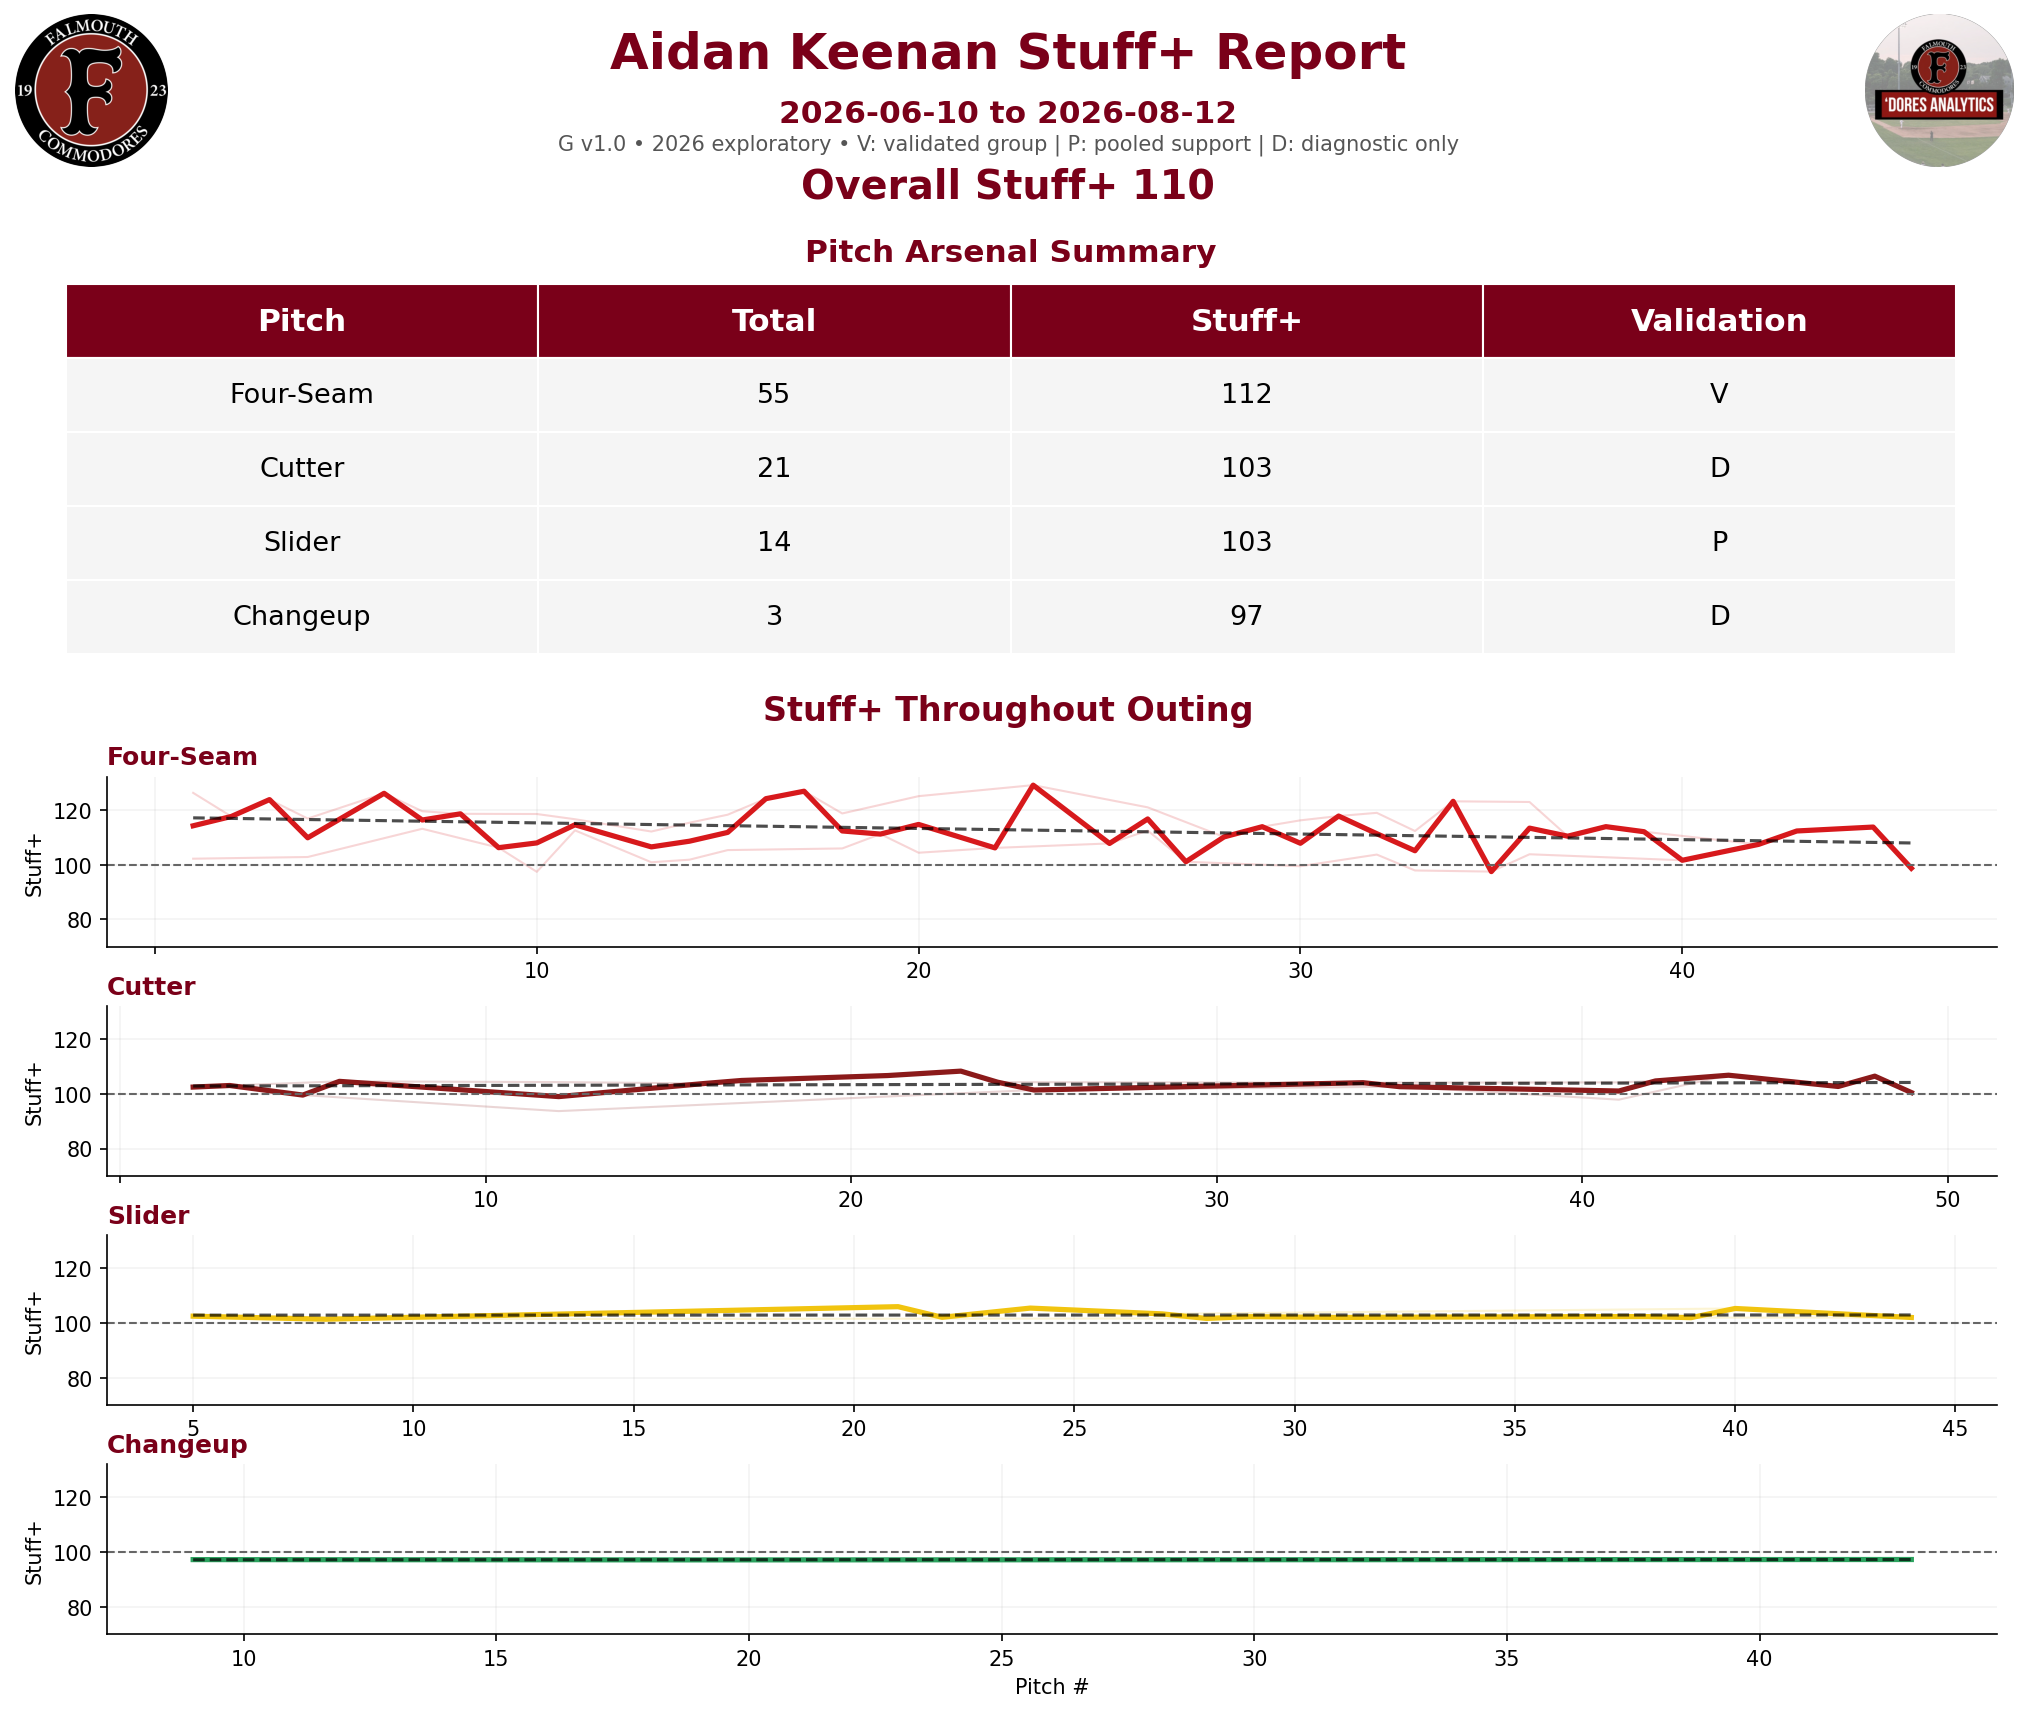

Saved report: C:\Users\brend\OneDrive\ccbl-stuff-plus\outputs\stuffplus_g_v1\run_20261005T210512_946621Z\reports\Pitcher_Report_G.png


In [19]:
if CREATE_REPORT:
    report_scores = load_saved_report_scores(REPORT_DATA_PATH, OUTPUT_PATH)

    report_validation = report_scores[
        report_scores.Pitcher.eq(PITCHER_NAME) & report_scores.Season.eq(SETTINGS.holdout_season)
        & report_scores.Date.between(REPORT_START_DATE, REPORT_END_DATE)
    ].groupby(["PitchType", "ReportPitchType", "PitcherThrows", "PublicationTier"], dropna=False).size().reset_index(name="PitchCount")
    report_validation.insert(0, "ModelVersion", MODEL_VERSION)
    report_validation.to_csv(REPORT_DIRECTORY / "Pitcher_Validation_G.csv", index=False)
    report_path = REPORT_DIRECTORY / "Pitcher_Report_G.png"

    generate_stuffplus_onepage_report(
        pitcher_name=PITCHER_NAME,
        scores=report_scores,
        start_date=REPORT_START_DATE,
        end_date=REPORT_END_DATE,
        save_path=report_path,
        left_logo_path=LEFT_LOGO_PATH,
        right_logo_path=RIGHT_LOGO_PATH,
        settings=SETTINGS,
    )
else:
    print("CREATE_REPORT=False: no report generated.")

Loaded saved pitch scores: C:\Users\brend\OneDrive\ccbl-stuff-plus\outputs\stuffplus_g_v1\run_20261005T210512_946621Z\StuffPlus_G_report_data.joblib


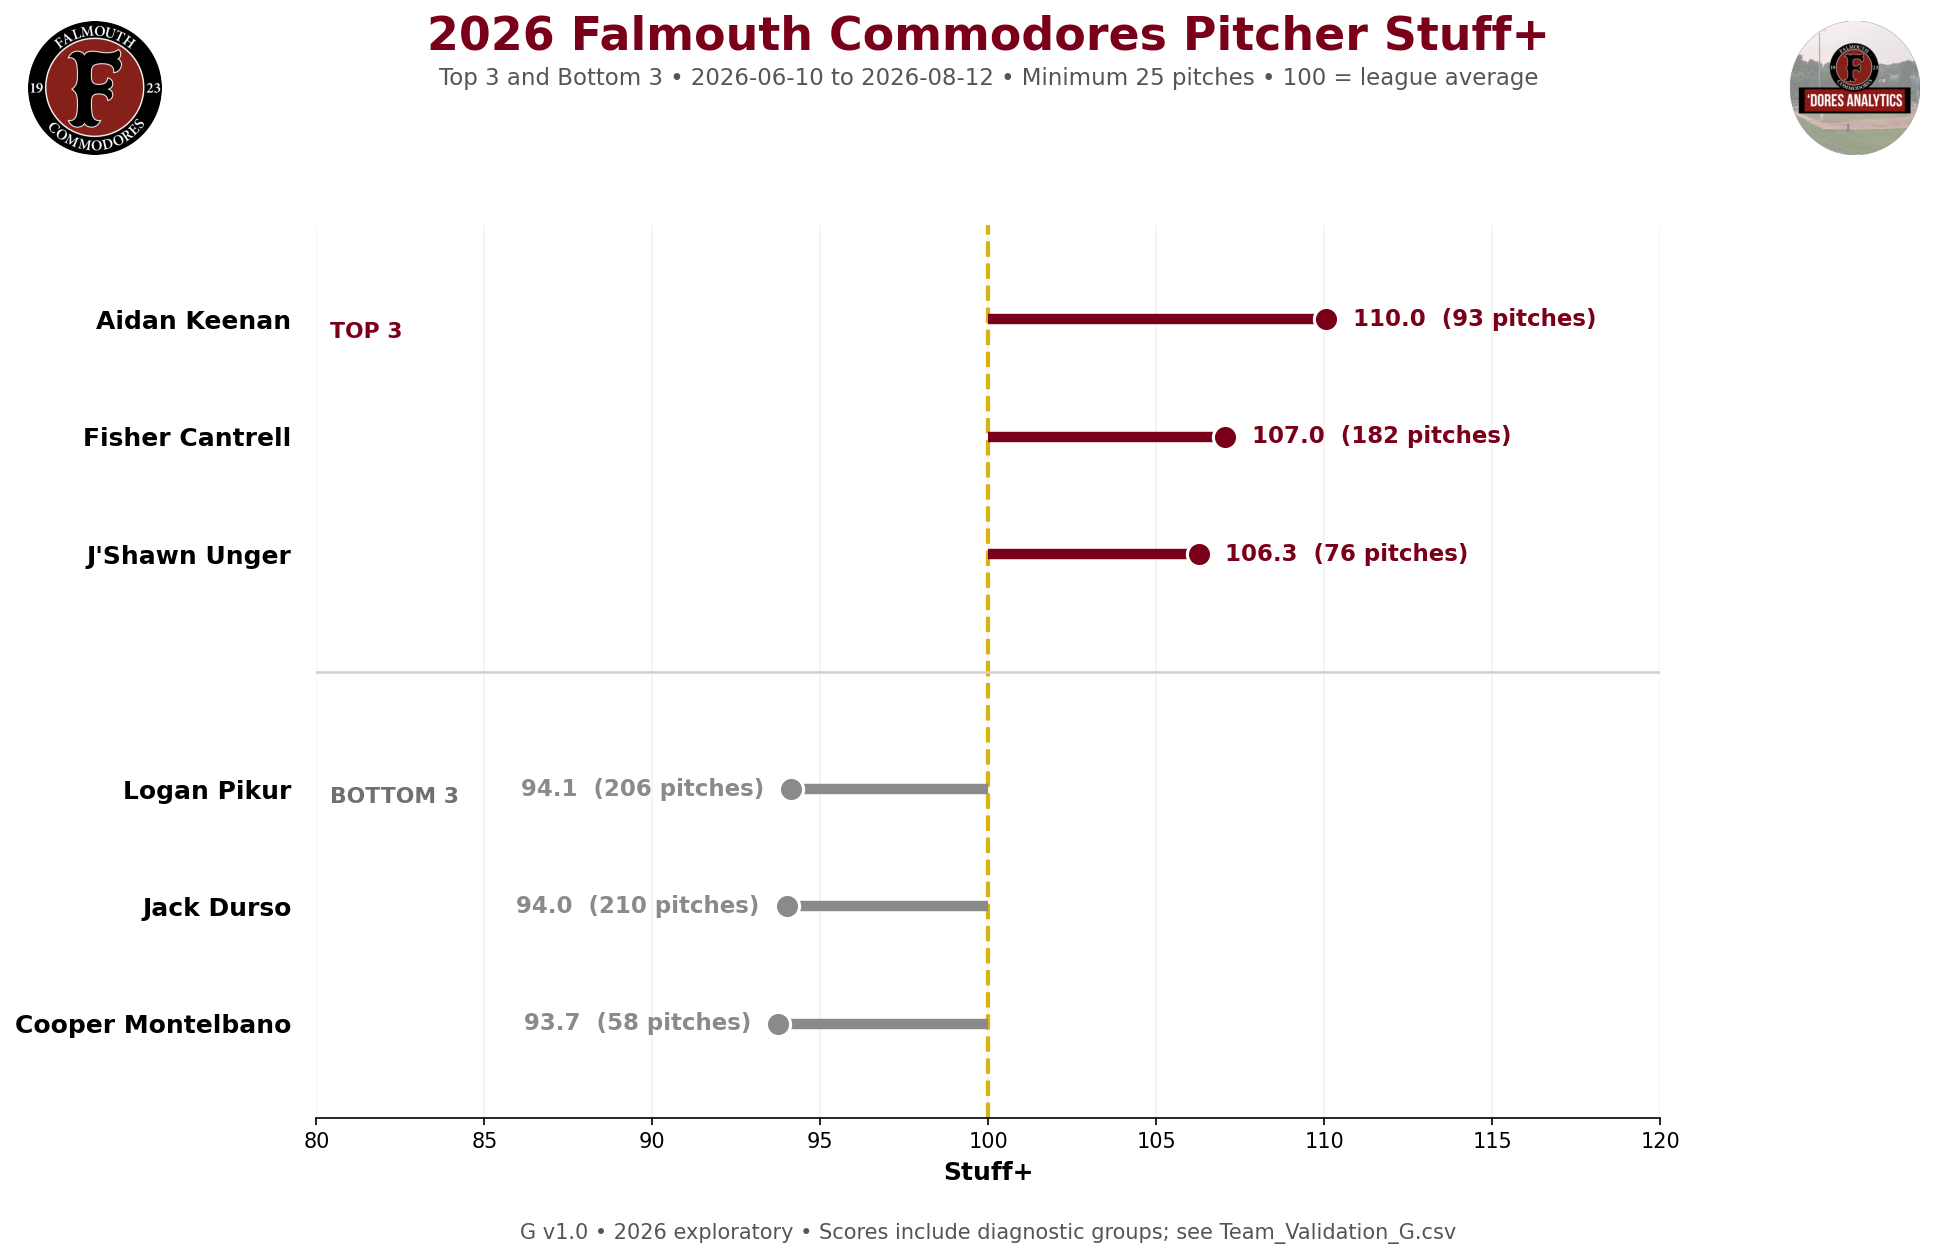

Saved team ranking graphic: C:\Users\brend\OneDrive\ccbl-stuff-plus\outputs\stuffplus_g_v1\run_20261005T210512_946621Z\reports\Team_Rankings_G.png

Pitchers shown in the ranking graphic:
           Pitcher  PitchCount StuffPlus RankingGroup
     Keenan, Aidan          93     110.0        Top 3
  Cantrell, Fisher         182     107.0        Top 3
    Unger, J'Shawn          76     106.3        Top 3
      Pikur, Logan         206      94.1     Bottom 3
       Durso, Jack         210      94.0     Bottom 3
Montelbano, Cooper          58      93.7     Bottom 3


In [20]:
if CREATE_TEAM_RANKING_GRAPHIC:
    team_ranking_scores = load_saved_report_scores(REPORT_DATA_PATH, OUTPUT_PATH)
    team_validation = team_ranking_scores[
        team_ranking_scores.Season.eq(TEAM_RANKING_SEASON) & team_ranking_scores.PitcherTeam.eq(TEAM_CODE)
        & team_ranking_scores.Date.between(REPORT_START_DATE, REPORT_END_DATE)
    ].groupby(["Pitcher", "PitchType", "ReportPitchType", "PitcherThrows", "PublicationTier"], dropna=False).size().reset_index(name="PitchCount")
    team_validation.insert(0, "ModelVersion", MODEL_VERSION)
    team_validation.to_csv(REPORT_DIRECTORY / "Team_Validation_G.csv", index=False)
    team_ranking_results = generate_team_pitcher_stuffplus_graphic(
        scores=team_ranking_scores,
        team_code=TEAM_CODE,
        season=TEAM_RANKING_SEASON,
        min_pitches=TEAM_RANKING_MIN_PITCHES,
        save_path=TEAM_RANKING_PATH,
        start_date=REPORT_START_DATE,
        end_date=REPORT_END_DATE,
        team_display_name=TEAM_DISPLAY_NAME,
        left_logo_path=LEFT_LOGO_PATH,
        right_logo_path=RIGHT_LOGO_PATH,
        settings=SETTINGS,
    )
    print("\nPitchers shown in the ranking graphic:")
    print(
        team_ranking_results[
            ["Pitcher", "PitchCount", "StuffPlus", "RankingGroup"]
        ].to_string(
            index=False,
            formatters={"StuffPlus": lambda value: f"{value:.1f}"},
        )
    )
else:
    print("CREATE_TEAM_RANKING_GRAPHIC=False: no team graphic generated.")